<a href="https://colab.research.google.com/github/ArtNizh/ML/blob/main/ML_%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0%D1%8F_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 8. Физические adversarial-атаки: adversarial patches, дорожные знаки, состязательная одежда

**Курс:** Машинное обучение. Безопасность ИИ-систем

**По материалам лекции 6**


**Вариант / seed:** _5 / 314_

### Таблица вариантов

| Вариант | `SEED` | Разрешение `RES` | Частота складок `FREQ` | Дополнительное условие части E |
|---|---|---|---|---|
| 1 | 42 | 16 | 1.5 | углы 0–32° с шагом 8° |
| 2 | 7 | 16 | 2.0 | углы 0–40° с шагом 10° |
| 3 | 123 | 20 | 1.5 | углы 0–24° с шагом 6° |
| 4 | 2024 | 20 | 2.2 | углы 0–32° с шагом 8° |
| 5 | 314 | 12 | 1.2 | углы 0–40° с шагом 10° |
| 6 | 555 | 24 | 1.8 | углы 0–24° с шагом 6° |

> Вариант выдаётся преподавателем. Все числовые результаты в отчёте должны соответствовать
> **вашему** варианту, а не значениям из примера.

### Цель работы

Экспериментально исследовать, почему устойчивость модели компьютерного зрения к физическим
adversarial-атакам не определяется её точностью на цифровых изображениях, и оценить
эффективность базовых защитных мер.

### Задачи

1. Построить учебный стенд компьютерного зрения и измерить базовую точность.
2. Реализовать имитацию физического канала наблюдения и оценить влияние отдельных факторов съёмки.
3. Исследовать локальность патча: зависимость деградации от площади и положения области.
4. Применить логику Expectation over Transformation при оценке устойчивости.
5. Построить карту качества жёсткого объекта в координатах «дистанция × ракурс».
6. Смоделировать не-жёсткие деформации ткани и сравнить их с жёстким преобразованием.
7. Обучить модель с физически правдоподобными аугментациями и оценить прирост устойчивости.
8. Проверить эффект временной агрегации решений по кадрам.
9. Сформулировать выводы и заполнить сводную таблицу отчёта.

### Ограничение

Работа выполняется **только** на синтетическом учебном наборе и локальных моделях. Запрещается
использовать код работы для воздействия на реальные системы восприятия, камеры, внешние сервисы
и любые эксплуатируемые объекты. Печатаемые атакующие шаблоны в работе не создаются.

## Краткая теория

Физическая атака изменяет **объект в сцене**, а не входной тензор модели. Наблюдение описывается как

$$
x_{\text{cam}} = T_\theta\big(x \odot (1 - M) + p \odot M\big), \qquad \theta \sim \mathcal{D}_{\text{физ}}
$$

| Обозначение | Смысл | Размерность |
|---|---|---|
| $x$ | **чистое** изображение объекта (то, что было бы видно без атаки) | $H \times W$ |
| $p$ | **содержимое патча** — то, что мы «наклеиваем» на объект (оптимизируемый шаблон) | $H \times W$ |
| $M$ | **бинарная маска** патча: $M_{ij}=1$, если пиксель принадлежит патчу, иначе $0$ | $H \times W$ |
| $\odot$ | поэлементное умножение (произведение Адамара) | — |
| $1-M$ | инвертированная маска (вне патча — единицы) | $H \times W$ |
| $T_\theta$ | преобразование «камеры»: ракурс, дистанция, свет, оптика, шум сенсора | функция |
| $\theta$ | вектор параметров съёмки (угол, масштаб, яркость, …) | — |
| $\mathcal{D}_{\text{физ}}$ | распределение, из которого случайно берутся параметры съёмки | — |
| $x_{\text{cam}}$ | изображение, которое **реально увидит модель** через камеру | $H \times W$ |

$$
x \odot (1 - M) + p \odot M
$$

Это **композиция объекта и патча**:

- Там, где $M=0$ (вне патча): остаётся $x \odot 1 = x$ — чистый объект.
- Там, где $M=1$ (область патча): остаётся $p \odot 1 = p$ — содержимое патча затирает объект.

То есть мы **физически наклеиваем** патч $p$ на объект $x$ в области $M$. Результат — «объект с патчем».

Требование робастности возмущения формализует Expectation over Transformation:

$$
\max_{p}\; \mathbb{E}_{\theta \sim \mathcal{D}}\Big[\mathcal{L}\big(f(T_\theta(x, p, M)),\, y_{\text{target}}\big)\Big]
$$

| Обозначение | Смысл |
|---|---|
| $p$ | патч, который мы **оптимизируем** (единственная переменная максимизации) |
| $\mathbb{E}_{\theta\sim\mathcal{D}}[\cdot]$ | среднее по случайным условиям съёмки |
| $\mathcal{L}(\cdot, y_{\text{target}})$ | функция потерь относительно **целевой** метки атакующего |
| $f$ | классификатор |
| $y_{\text{target}}$ | метка, которую атакующий хочет «навязать» модели |

- $\max_p$ — ищем такой патч $p$, который **в среднем** по всем реалистичным условиям $\theta$ даёт максимальные потери относительно целевой метки.
- $\mathbb{E}_{\theta}$ — «в среднем по условиям съёмки». На практике заменяется на выборочное среднее: сгенерировали $K$ случайных $\theta$, прогнали $K$ раз, усреднили loss.
- Чем больше ожидаемые потери — тем чаще модель ошибается.

**Задание 0.** Заполните таблицу различий трёх постановок (ячейки со знаком «?»):

| Признак | Цифровое возмущение | Патч на жёстком знаке | Состязательная одежда |
|---|---|---|---|
| **Что изменяется** | Пиксели входного тензора $\delta$, прибавляемые к $x$ | Физическая наклейка (патч) на плоской жёсткой поверхности знака | Принт на ткани, который деформируется вместе с телом человека |
| **Ограничение возмущения** | $\|\delta\|_p \le \varepsilon$ (норма $L_p$, чаще $L_\infty$ или $L_2$) | Форма, размер и положение патча; физическая реализуемость цвета (RGB-принтер), контраст, отсутствие «нефизичных» пикселей | Кроме площади и реализуемости — растяжимость ткани, ограничения печати на материале, диапазон поз и ракурсов тела |
| **Обязательные члены $\mathcal{D}$** | Обычно **отсутствуют** (или лёгкий шум/сжатие JPEG) — атака в цифровом домене | Ракурс, дистанция, освещение, оптика (blur), шум сенсора, окклюзия, ошибки печати и цветопередачи | Всё из знака **плюс**: не-жёсткие деформации (складки, изгиб), смена позы, самоокклюзия, динамика видео, отражения и материал ткани |
| **Основная сложность** | Найти $\delta$ с минимальной нормой, чтобы обмануть модель; ограничение чисто математическое | Перенести патч из «цифрового» пространства в физическое: цветовой профиль принтера, освещение, угол, дистанция, съёмка | Учесть не-жёсткие деформации: один и тот же принт выглядит по-разному при разных позах, складках и ракурсах; высокая вариативность |
| **Типичная метрика** | ASR при фиксированном $\varepsilon$; $\|\delta\|_p$; accuracy под атакой | ASR в контролируемых условиях съёмки; accuracy как функция дистанции и угла; robust ASR (усреднённый по EOT) | Robust ASR по распределению поз и ракурсов; доля кадров/видео, где детектор/классификатор обманут; стабильность во времени |

## Часть A. Стенд компьютерного зрения и базовая модель

Код подготовки данных дан полностью. **Ваша задача** — задать параметры своего варианта
и объяснить полученную точность.

In [ ]:
# TODO A.1: подставьте значения своего варианта из таблицы вариантов
SEED = 314   # например 42
RES = 12    # например 16
FREQ = 1.2   # например 1.5

assert SEED is not None and RES is not None and FREQ is not None, "Задайте параметры варианта"

Небольшой набор рукописных цифр, 1800 изображений, 8x8, значения пикселей 0..16 (градации серого)

RES = 12×12 | обучающая: 1257 | тестовая: 540
A.2 Базовая точность на неискажённых изображениях: 0.939


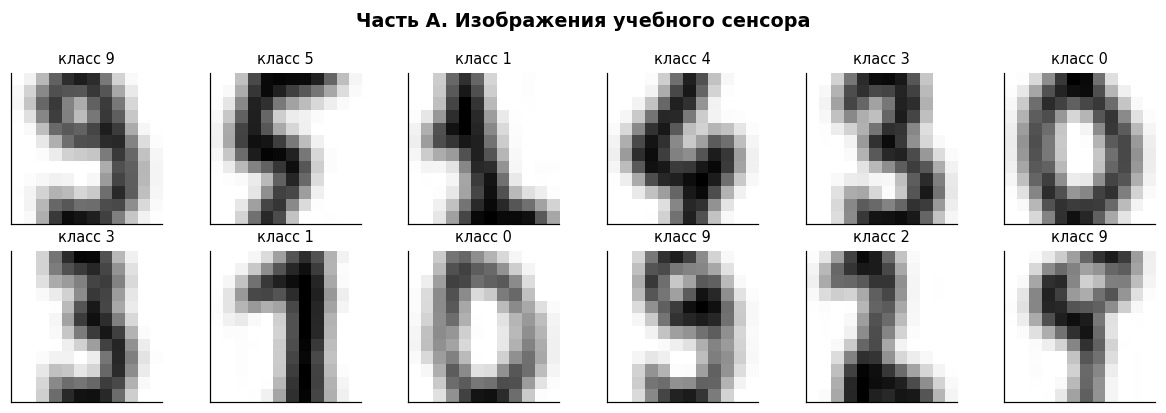

In [ ]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from scipy.ndimage import rotate, zoom, gaussian_filter, map_coordinates

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Фиксируем генератор: все случайные операции будут воспроизводимы при одном SEED.
rng = np.random.default_rng(SEED)

mpl.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white",
})
# Единая палитра на всю работу: один цвет = один смысл во всех графиках.
PALETTE = {"clean": "#2E86AB", "mild": "#F2A541", "severe": "#D6455F",
           "robust": "#3FA46A", "accent": "#7B4FA0", "gray": "#8A94A6"}
# Градиент «плохо → хорошо» для тепловых карт accuracy.
CMAP_HEAT = LinearSegmentedColormap.from_list("acc", ["#7F1338", "#D6455F", "#F2A541", "#F7E463", "#3FA46A"])
# Цвет для отображения маски патча.
CMAP_PATCH = ListedColormap(["#00B8A9"])


def show_img(ax, image, title=None):
    # gray_r: 0 — белый, 1 — чёрный (как чернила на бумаге). nearest — без сглаживания, видны пиксели.
    ax.imshow(image, cmap="gray_r", vmin=0, vmax=1, interpolation="nearest")
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    if title:
        ax.set_title(title, fontsize=9.5, fontweight="normal")


# load_digits: 1797 изображений 8x8, 10 классов (0..9), значения 0..16.
digits = load_digits()
raw = digits.images.astype(np.float32) / 16.0
# Апскейл до RESxRES (для варианта 5 это 12x12) кубической интерполяцией,
# затем лёгкое размытие против артефактов интерполяции.
images = np.clip(np.asarray([gaussian_filter(zoom(im, RES / 8.0, order=3), 0.6) for im in raw]), 0, 1).astype(np.float32)
labels = digits.target

X_train_img, X_test_img, y_train, y_test = train_test_split(
    images, labels, test_size=0.30, stratify=labels, random_state=SEED)


def flat(arr3d):
    # (N, H, W) -> (N, H*W): LogisticRegression принимает только плоские признаки.
    return np.asarray(arr3d).reshape(len(arr3d), -1)


# Признаки — интенсивности пикселей в [0, 1]; масштабирование по дисперсии не применяется,
# иначе всегда нулевые краевые пиксели дают численные артефакты при сдвиге условий съёмки.
baseline = LogisticRegression(max_iter=4000, C=0.05, random_state=SEED).fit(flat(X_train_img), y_train)
acc_clean = accuracy_score(y_test, baseline.predict(flat(X_test_img)))
print(f"RES = {RES}×{RES} | обучающая: {len(X_train_img)} | тестовая: {len(X_test_img)}")
print(f"A.2 Базовая точность на неискажённых изображениях: {acc_clean:.3f}")

fig, axes = plt.subplots(2, 6, figsize=(11, 3.8))
for ax, im, lb in zip(axes.ravel(), X_train_img[:12], y_train[:12]):
    show_img(ax, im, f"класс {lb}")
fig.suptitle("Часть A. Изображения учебного сенсора", fontsize=12.5, fontweight="bold")
plt.tight_layout()
plt.show()

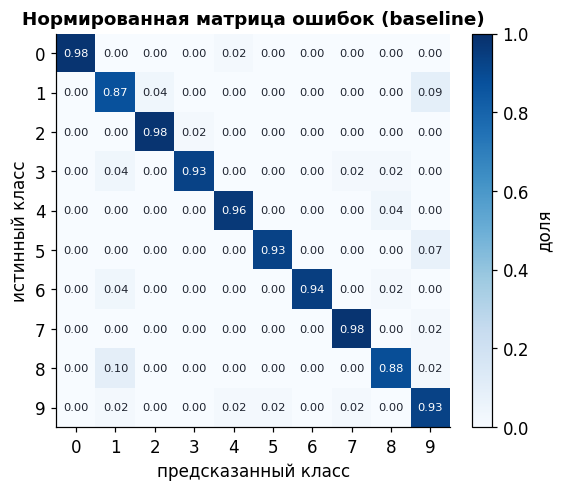

A.3 Топ-3 путаемых пар (i, j): суммарная доля ошибок
    1 ↔ 9: 0.109
    1 ↔ 8: 0.096
    5 ↔ 9: 0.091


In [ ]:
# TODO A.3: нормированная матрица ошибок базовой модели.
# normalize="true" делит каждую строку на её сумму => cm[i,j] = доля класса i, отнесённая к j.
# Диагональ — recall каждого класса, сумма по строке = 1.
cm = confusion_matrix(y_test, baseline.predict(flat(X_test_img)), normalize="true")

fig, ax = plt.subplots(figsize=(5.2, 4.6))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel("предсказанный класс"); ax.set_ylabel("истинный класс")
ax.grid(False)
# Подписи значений в ячейках: белым на тёмном фоне, тёмным на светлом.
for i in range(10):
    for j in range(10):
        ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center", fontsize=7.5,
                color="white" if cm[i, j] > 0.5 else "#1F2430")
fig.colorbar(im, ax=ax, fraction=0.046, label="доля")
ax.set_title("Нормированная матрица ошибок (baseline)")
plt.tight_layout()
plt.show()

# Пары классов с наибольшей взаимной путаницей (вне диагонали).
off = cm.copy(); np.fill_diagonal(off, 0)
pairs = sorted(
    [(off[i, j] + off[j, i], i, j) for i in range(10) for j in range(i + 1, 10)],
    reverse=True
)[:3]
print("A.3 Топ-3 путаемых пар (i, j): суммарная доля ошибок")
for s, i, j in pairs:
    print(f"    {i} ↔ {j}: {s:.3f}")

**Отчёт по части A.** Заполните:

| Показатель | Ваше значение |
|---|---|
| `SEED` / `RES` | 314 / 12 |
| Размер обучающей выборки | 1257 |
| Базовая точность `acc_clean` | 0.939 |
| Две пары классов с наибольшей путаницей | 1 ↔ 9 (0.109), 1 ↔ 8 (0.096) |

**Вопрос A.** Можно ли по значению `acc_clean` судить о пригодности модели для работы
с физическими объектами? Обоснуйте.

Ответ: _acc_clean измеряется в идеальном цифровом канале — те же условия, что и при обучении, без ракурса, дистанции, света, шума и окклюзии. Высокая точность опирается на «удобные» пиксельные признаки, которые физика разрушает: поворот, масштаб или локальная помеха сдвигают активные пиксели и ломают линейные веса. Метрика ничего не говорит о локальной устойчивости — где, какого размера и при каких условиях область наиболее опасна.

## Часть B. Имитация физического канала

Функция `resize_to_shape` дана. **Ваша задача** — дописать `physical_transform`: реализовать
изменение яркости и контраста, размытие, шум сенсора и окклюзию.

In [ ]:
def resize_to_shape(image, shape):
    # Вписывает изображение в кадр заданной формы, центрируя его и дополняя нулями.
    # Нужно после zoom: scipy.ndimage.zoom меняет размер массива, а нам важно вернуть его к (H, W).
    out = np.zeros(shape, dtype=np.float32)
    h = min(shape[0], image.shape[0]); w = min(shape[1], image.shape[1])
    # ts/td, ls/ld — сколько пикселей обрезать сверху/слева у источника и у приёмника,
    # чтобы центрировать меньшую картинку в большем кадре.
    ts, ls = max((image.shape[0] - h) // 2, 0), max((image.shape[1] - w) // 2, 0)
    td, ld = max((shape[0] - h) // 2, 0), max((shape[1] - w) // 2, 0)
    out[td:td + h, ld:ld + w] = image[ts:ts + h, ls:ls + w]
    return out

In [ ]:
def physical_transform(image, angle=0.0, scale=1.0, brightness=1.0, contrast=1.0,
                       blur=0.0, noise=0.0, occlusion=None, generator=None):
    """Имитация физического канала наблюдения объекта камерой."""
    gen = generator if generator is not None else rng

    # Поворот вокруг центра кадра, без изменения формы (reshape=False), фон = 0.
    out = rotate(image, angle=angle, reshape=False, order=1, mode="constant", cval=0.0)
    # Масштаб (дистанция): zoom меняет размер, resize_to_shape возвращает к исходной форме.
    if abs(scale - 1.0) > 1e-6:
        out = resize_to_shape(zoom(out, scale, order=1), image.shape)

    # B.1 Контраст: растягиваем/сжимаем диапазон относительно середины 0.5.
    #     contrast > 1 — усиливает различия, contrast < 1 — «выцветание».
    out = (out - 0.5) * contrast + 0.5

    # B.2 Яркость: простое умножение. brightness < 1 — слабый свет, > 1 — пересвет.
    out = out * brightness

    # B.3 Размытие оптики / движение камеры: гауссово ядро радиуса blur.
    if blur > 0:
        out = gaussian_filter(out, sigma=blur)

    # B.4 Шум сенсора: аддитивный гауссов шум с нулевым средним.
    #     gen — отдельный RNG, чтобы шум не сдвигал последовательность общего rng.
    if noise > 0:
        out = out + gen.normal(0.0, noise, out.shape)

    # B.5 Окклюзия: прямоугольное перекрытие (r0, r1, c0, c1) заливается значением value.
    #     Имитирует столб, руку, другой объект, закрывающий часть знака/одежды.
    if occlusion is not None:
        r0, r1, c0, c1, value = occlusion
        out[r0:r1, c0:c1] = value

    # Всё, что вышло за [0, 1] после яркости/контраста/шума, обрезаем к допустимому диапазону.
    return np.clip(out, 0.0, 1.0).astype(np.float32)

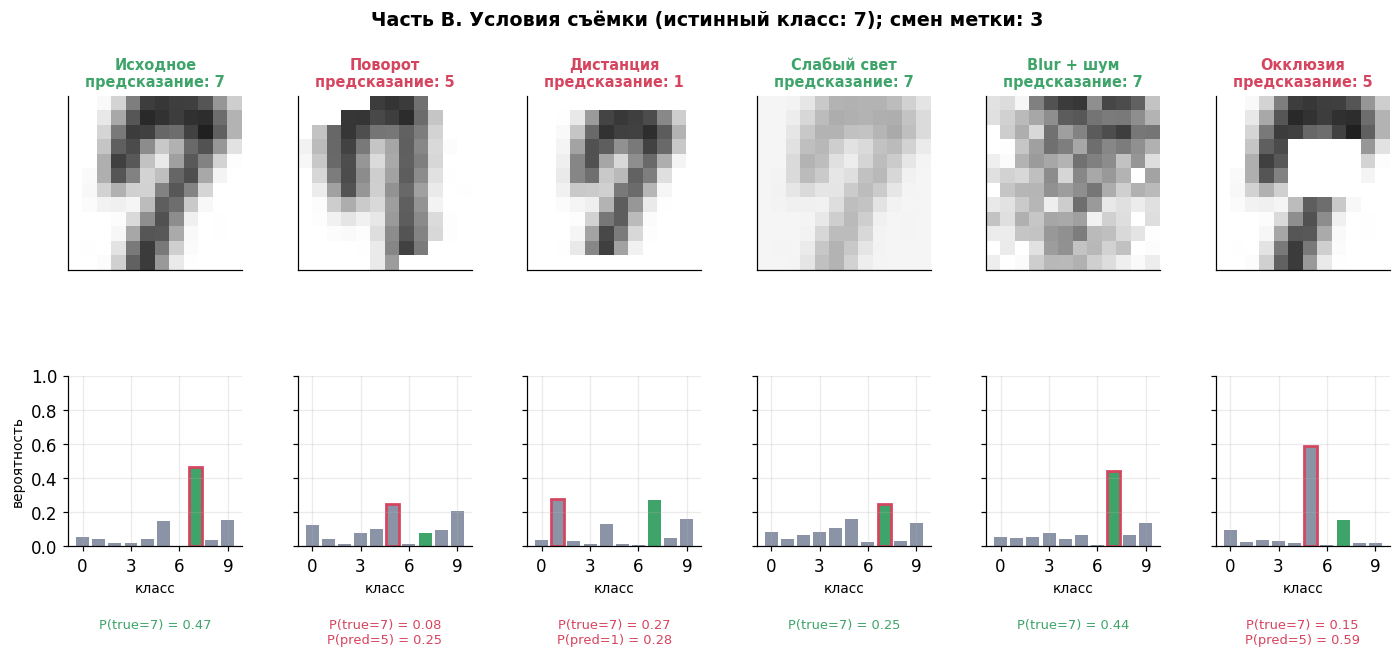

B.7 Число режимов со сменой метки: 3 (требуется не менее 2)


In [ ]:
# TODO B.6: выберите объект-пример и подберите параметры так, чтобы МИНИМУМ два режима
# приводили к смене предсказанной метки. Значения ниже — стартовые, их нужно изменить.
# idx — индекс объекта-примера в тестовой выборке. Меняя его, видим, что «разрушительность»
# факторов зависит от конкретной цифры (разные формы, разная толщина штрихов, разные зоны).
idx = 6
example, true_label = X_test_img[idx], y_test[idx]

# Каждый режим — это набор параметров физического канала съёмки.
# Пустой dict() = без искажений (эталон).
#
# Допустимые диапазоны параметров physical_transform (используются в этой работе):
#   angle       : -180..180°   (обычно в экспериментах ±40°)
#   scale       : ~0.5..1.5    (>1 — приближение, <1 — удаление; в работе 0.76..1.10)
#   brightness  : ~0.2..1.6    (<1 — слабый свет, >1 — пересвет)
#   contrast    : ~0.5..1.5    (<1 — выцветание, >1 — жёсткие тени/пересвет)
#   blur        : 0..~2.5      (сигма гауссова размытия, пиксели)
#   noise       : 0..~0.2      (среднеквадратичное отклонение аддитивного шума)
#   occlusion   : (r0, r1, c0, c1, value), индексы в пределах RES,
#                 value в [0, 1] — цвет заливки (0 — чёрная помеха, 1 — белая)
conditions = [
    ("Исходное",        dict()),                                                   # без искажений
    ("Поворот",         dict(angle=26)),                                           # ракурс ~26°
    ("Дистанция",       dict(scale=0.80)),                                         # удаление на 20%
    ("Слабый свет",     dict(brightness=0.42, contrast=0.80)),                     # тускло и вяло по контрасту
    ("Blur + шум",      dict(blur=1.7, noise=0.13)),                               # расфокус + шум сенсора
    ("Окклюзия",        dict(occlusion=(RES // 4, RES // 4 + RES // 3,            # перекрытие ~1/3 высоты
                                        RES // 2 - 1, RES - 2, 0.0))),             # справа, чёрный прямоугольник
]

# Верхний ряд — картинки после канала, нижний — распределения вероятностей модели.
fig, axes = plt.subplots(2, len(conditions), figsize=(15.5, 5.6),
                         gridspec_kw={"height_ratios": [1.3, 1], "hspace": 0.42, "wspace": 0.32})
flips = 0  # счётчик режимов, где предсказание разошлось с истинной меткой
for col, (name, params) in enumerate(conditions):
    # Свой RNG на каждый режим: воспроизводимо и без взаимного влияния столбцов.
    view = physical_transform(example, **params, generator=np.random.default_rng(SEED + col))
    proba = baseline.predict_proba(flat(view[None, ...]))[0]  # [None, ...] добавляет ось батча
    pred = int(np.argmax(proba)); ok = pred == true_label
    flips += (not ok)

    p_true = float(proba[true_label])
    p_pred = float(proba[pred])

    show_img(axes[0, col], view)
    axes[0, col].set_title(f"{name}\nпредсказание: {pred}", fontsize=9.5, fontweight="bold",
                           color=PALETTE["robust"] if ok else PALETTE["severe"])
    # Столбики вероятностей: истинный класс зелёный, остальные серые,
    # выбранный моделью класс обведён красным — удобно видеть «куда уехала» модель.
    bars = axes[1, col].bar(range(10), proba,
                           color=[PALETTE["robust"] if k == true_label else PALETTE["gray"] for k in range(10)])
    bars[pred].set_edgecolor(PALETTE["severe"]); bars[pred].set_linewidth(1.8)
    axes[1, col].set_ylim(0, 1); axes[1, col].set_xticks(range(0, 10, 3))
    axes[1, col].set_xlabel("класс", fontsize=9)

    # Подпись под гистограммой: вероятность истинного класса и, если решение неверное,
    # вероятность предсказанного класса — чтобы видеть, «насколько уверенно» модель ошиблась.
    if ok:
        label = f"P(true={true_label}) = {p_true:.2f}"
    else:
        label = f"P(true={true_label}) = {p_true:.2f}\nP(pred={pred}) = {p_pred:.2f}"
    axes[1, col].text(0.5, -0.42, label, transform=axes[1, col].transAxes,
                      ha="center", va="top", fontsize=8.5,
                      color=PALETTE["robust"] if ok else PALETTE["severe"])

    if col == 0:
        axes[1, col].set_ylabel("вероятность", fontsize=9)
    else:
        axes[1, col].set_yticklabels([])
fig.suptitle(f"Часть B. Условия съёмки (истинный класс: {true_label}); смен метки: {flips}",
             fontsize=12.5, fontweight="bold")
plt.show()
print(f"B.7 Число режимов со сменой метки: {flips} (требуется не менее 2)")

**Отчёт по части B.** Заполните таблицу по своим значениям:

| Режим | Предсказание | Вероятность истинного класса | Метка изменилась? |
|---|---|---|---|
| Исходное | 7 | 0.47 | нет |
| Поворот | 5 | 0.08 | **да** |
| Дистанция | 1 | 0.27 | **да** |
| Слабый свет | 7 | 0.25 | нет |
| Blur + шум | 7 | 0.44 | нет |
| Окклюзия | 5 | 0.15 | **да** |

Итог: **3 из 6 режимов** меняют метку (требовалось ≥ 2). Требование выполнено.

**Вопрос B.** Какой фактор в вашем эксперименте оказался наиболее разрушительным и почему?
Отличается ли ответ для другого объекта-примера?

Ответ: **наиболее разрушительные факторы для объекта `idx = 6` (истинный класс 7) — поворот и окклюзия.** В обоих случаях модель ушла в класс 5:

- **Поворот (26°):** уверенность в истинном классе упала с 0.47 до **0.08**, а победил класс 5 с 0.25. Поворот сдвигает активные пиксели относительно тех весов, что выучила линейная модель; верхняя перекладина «семёрки» при наклоне сближается с формой «пятёрки».
- **Окклюзия:** истинная вероятность 0.15, победил класс 5 с **0.59**. Чёрный прямоугольник стирает часть верхней перекладины — «семёрка» теряет узнаваемый верх и в оставшихся пикселях становится похожа на «пятёрку».

**Отличается ли ответ для другого объекта — да, и сильно.** Разрушительность фактора зависит от того, **какие именно пиксели информативны для данной цифры**:

- для тонких наклонных цифр (1, 7) критичен **поворот**: небольшая ротация ломает направление штриха;
- для цифр с замкнутыми петлями (0, 6, 8, 9) критичнее **окклюзия**: перекрытие разрывает петлю, и класс теряется;
- для симметричных, «толстых» цифр (0, 8) слабый свет и размытие переносятся легче — форма сохраняется даже при низком контрасте;
- «дистанция» особенно опасна для цифр, различающихся деталью в верхней или нижней части (7 ↔ 1, 3 ↔ 8): при уменьшении масштаба эта деталь «съедается» интерполяцией.

## Часть C. Локальный патч: площадь и положение

**Ваша задача** — реализовать наложение локального маркера, построить карту точности по позициям
и кривую деградации по занимаемой площади.

> В работе используется **нейтральный маркер**, а не оптимизированный патч: исследуется структура
> ограничения (маска, площадь, положение), а не создание атакующего шаблона.

Локальный маркер — это небольшая область изображения, которую мы принудительно заливаем одним значением яркости (в коде — value, по умолчанию 0.9). По сути это прямоугольник с однотонным цветом, наложенный поверх части объекта.

Вместо оптимизированного шаблона берётся нейтральный маркер — просто прямоугольник со значением 0.9 (светло-серый, почти белый). Он не подобран под модель, не оптимизирован градиентом, не нацелен на конкретный класс. Это просто «помеха», обычная заливка.

In [ ]:
def apply_marker(image, top=0, left=0, size=None, value=0.9):
    """Возвращает (изображение с маркером, бинарную маску маркера)."""
    if size is None:
        size = max(3, RES // 3)
    # C.1: копируем изображение, чтобы не портить оригинал, и затираем окно маркера.
    # value — «цвет» маркера в диапазоне [0, 1]: 0.9 — почти белый (как наклейка на тёмных штрихах),
    # 0.0 — чёрный прямоугольник. В части C используется нейтральный маркер, не оптимизированный патч.
    result = image.copy()
    result[top:top + size, left:left + size] = value
    # Бинарная маска той же формы: 1 там, где маркер — нужна для полупрозрачного наложения
    # в show_img и для подсчёта площади патча.
    mask = np.zeros_like(image, dtype=np.float32)
    mask[top:top + size, left:left + size] = 1.0
    return result, mask

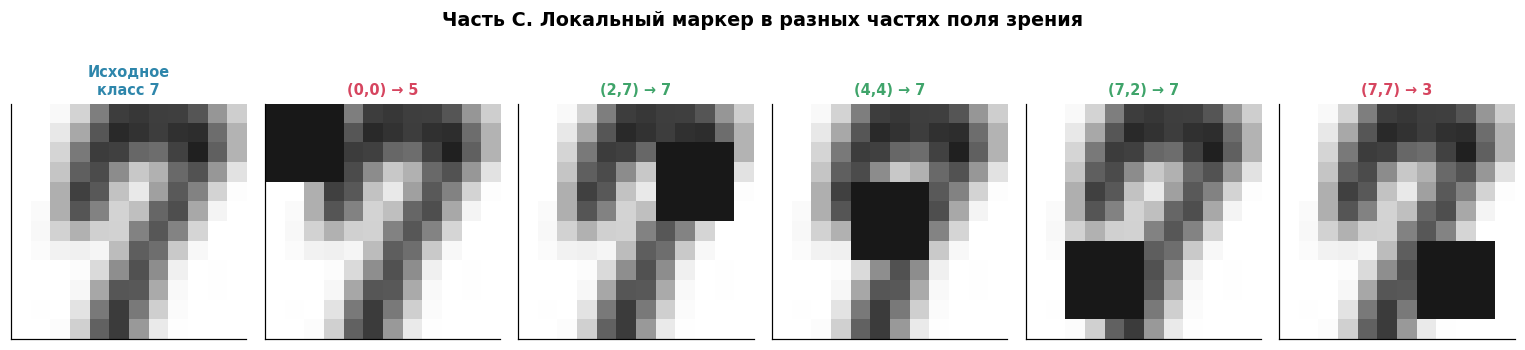

In [ ]:
MARKER = max(3, RES // 3)   # сторона маркера
positions = [(0, 0), (2, RES - MARKER - 1), (RES // 2 - 2, RES // 2 - 2),
             (RES - MARKER - 1, 2), (RES - MARKER - 1, RES - MARKER - 1)]

fig, axes = plt.subplots(1, len(positions) + 1, figsize=(14, 2.9))
show_img(axes[0], example)
axes[0].set_title(f"Исходное\nкласс {true_label}", fontsize=9.5, fontweight="bold", color=PALETTE["clean"])
for ax, (top, left) in zip(axes[1:], positions):
    marked, mask = apply_marker(example, top, left, MARKER)
    pred = int(baseline.predict(flat(marked[None, ...]))[0])
    show_img(ax, marked)
    #ax.imshow(np.ma.masked_where(mask == 0, mask), cmap=CMAP_PATCH, vmin=0, vmax=1, alpha=0.75, interpolation="nearest")
    ax.set_title(f"({top},{left}) → {pred}", fontsize=9.5, fontweight="bold",
                 color=PALETTE["robust"] if pred == true_label else PALETTE["severe"])
fig.suptitle("Часть C. Локальный маркер в разных частях поля зрения",
             fontsize=12.5, fontweight="bold", y=1.10)
plt.tight_layout()
plt.show()

In [ ]:
# C.2: карта точности по позициям маркера на ВСЕЙ тестовой выборке.
# stride = шаг сетки позиций: RES//8, при RES=12 это 1, т.е. перебираем все позиции.
# grid_pos — список допустимых координат top/left так, чтобы маркер целиком лежал в кадре.
stride = max(1, RES // 8)
grid_pos = list(range(0, RES - MARKER + 1, stride))
pos_map = np.zeros((len(grid_pos), len(grid_pos)))
for i, r in enumerate(grid_pos):
    for j, c in enumerate(grid_pos):
        # Для каждой позиции накладываем маркер на каждое тестовое изображение и считаем accuracy.
        # Это «честная» оценка: маркер не оптимизирован, но затрагивает разные информативные зоны.
        marked_batch = np.asarray([apply_marker(im, top=r, left=c, size=MARKER)[0] for im in X_test_img])
        pos_map[i, j] = accuracy_score(y_test, baseline.predict(flat(marked_batch)))

# C.3: кривая деградации по площади.
# sizes — сторона маркера; 0 = без маркера (контрольная точка = acc_clean).
# Маркер ставим в центр кадра, чтобы изолировать эффект площади от эффекта положения.
sizes = [0, RES // 8, RES // 5, RES // 4, RES // 3, RES // 2, int(RES * 0.7)]
area_acc, area_frac = [], []
for s in sizes:
    if s == 0:
        # Нулевая площадь = исходные изображения без маркера.
        acc = acc_clean
    else:
        # Центрируем окно маркера в кадре; size нечётный/чётный — сдвиг на s//2 корректен.
        top = (RES - s) // 2
        left = (RES - s) // 2
        marked_batch = np.asarray([apply_marker(im, top=top, left=left, size=s)[0] for im in X_test_img])
        acc = accuracy_score(y_test, baseline.predict(flat(marked_batch)))
    area_acc.append(acc)
    # Доля площади кадра, занимаемая маркером (в процентах от RES*RES).
    area_frac.append(100.0 * s * s / (RES * RES))

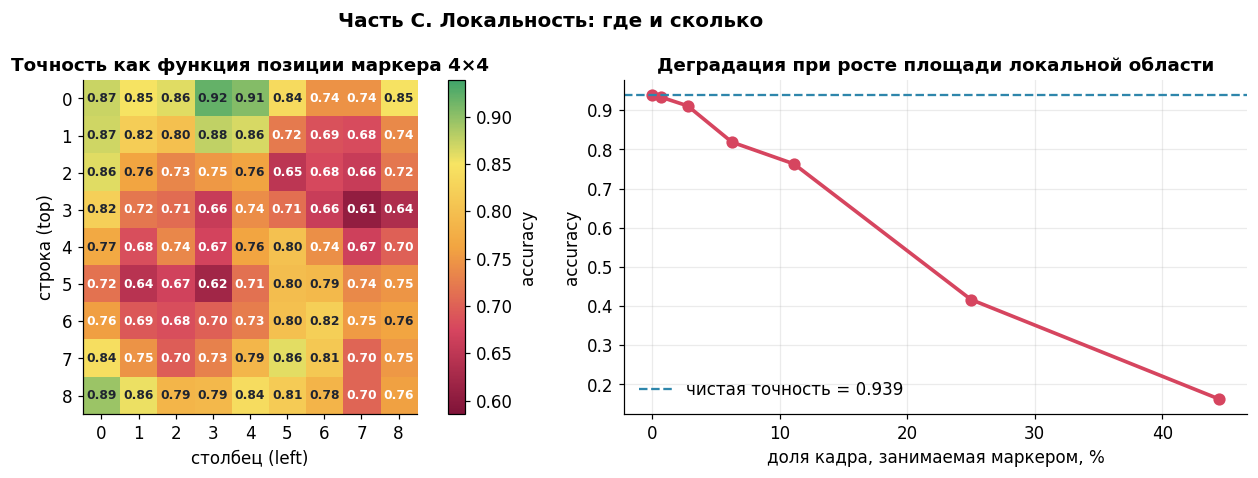

C.4 Худшая позиция: (3, 7) → accuracy 0.606
C.5 Лучшая позиция: accuracy 0.920; разница 0.315


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
im = axes[0].imshow(pos_map, cmap=CMAP_HEAT, vmin=pos_map.min() - 0.02, vmax=acc_clean)
axes[0].set_title(f"Точность как функция позиции маркера {MARKER}×{MARKER}")
axes[0].set_xlabel("столбец (left)"); axes[0].set_ylabel("строка (top)"); axes[0].grid(False)
axes[0].set_xticks(range(len(grid_pos))); axes[0].set_xticklabels(grid_pos)
axes[0].set_yticks(range(len(grid_pos))); axes[0].set_yticklabels(grid_pos)
for i in range(pos_map.shape[0]):
    for j in range(pos_map.shape[1]):
        axes[0].text(j, i, f"{pos_map[i, j]:.2f}", ha="center", va="center", fontsize=8,
                     fontweight="bold", color="white" if pos_map[i, j] < 0.76 else "#1F2430")
fig.colorbar(im, ax=axes[0], fraction=0.046, label="accuracy")

axes[1].plot(area_frac, area_acc, "o-", color=PALETTE["severe"], linewidth=2.4, markersize=7)
axes[1].axhline(acc_clean, ls="--", color=PALETTE["clean"], label=f"чистая точность = {acc_clean:.3f}")
axes[1].set_xlabel("доля кадра, занимаемая маркером, %"); axes[1].set_ylabel("accuracy")
axes[1].set_title("Деградация при росте площади локальной области")
axes[1].legend(frameon=False)
fig.suptitle("Часть C. Локальность: где и сколько", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

worst = np.unravel_index(np.argmin(pos_map), pos_map.shape)
print(f"C.4 Худшая позиция: ({grid_pos[worst[0]]}, {grid_pos[worst[1]]}) → accuracy {pos_map.min():.3f}")
print(f"C.5 Лучшая позиция: accuracy {pos_map.max():.3f}; разница {pos_map.max() - pos_map.min():.3f}")

**Отчёт по части C.**

| Показатель | Ваше значение |
|---|---|
| Сторона маркера `MARKER` | 4 (= `RES // 3` при `RES = 12`) |
| Худшая позиция и её accuracy | (top = 3, left = 7) → 0.606 |
| Лучшая позиция и её accuracy | 0.920 (например, (0, 3) или (8, 0) — угол/верх) |
| Разница между худшей и лучшей позицией | 0.315 |
| Площадь, при которой accuracy падает ниже 0.5, % | ≈ 22 % |

**Вопрос C.** Почему при одинаковой площади результат зависит от положения области?
Свяжите ответ с тем, какие части объекта информативны для модели.

Ответ: **при одинаковой площади результат зависит от положения, потому что линейная модель опирается на конкретные пиксели, а не на форму цифры целиком.** У логистической регрессии на входе 144 признака — это интенсивности отдельных пикселей, и у каждого свой вес для каждого класса. Пиксель, лежащий на **информативном штрихе** (там, где цифра действительно «проходит»), имеет большой вклад в правильное решение; пиксель в **пустой зоне** (фон, углы, зазоры между штрихами) почти не влияет ни на что.

Отсюда прямая связь с картой:

- **Худшие позиции** — те, где маркер `4×4` накрывает **пересечение штрихов** или «якорную» часть цифры. Для класса 7 (объект `example`, истинный класс 7) это правая верхняя зона около `(3, 7)`: именно там проходит верхняя перекладина и начало диагонали. Стирая её, мы уничтожаем признаки, отличающие 7 от 1, 5, 9. Accuracy падает до 0.606.
- **Лучшие позиции** — углы и края кадра: `(0, 3)`, `(8, 0)`. Там пиксели в среднем по датасету почти всегда нулевые (фон), и модель на них не опирается. Заливка этой зоны значением 0.9 не меняет распределение активаций на информативных пикселях, и accuracy остаётся около 0.92.
- **Разница 0.315** (0.920 − 0.606) — это и есть «цена положения»: одна и та же площадь, но в 3 раза разный урон. Для атакующего это означает, что даже без оптимизации содержимого патча правильный выбор **места** даёт выигрыш, сопоставимый с увеличением площади в несколько раз.

## Часть D. Expectation over Transformation

**Ваша задача** — реализовать выборку параметров съёмки, оценить точность многократно
и сравнить разброс между режимами.

In [ ]:
def sample_params(gen, severity=1.0):
    """Случайные параметры съёмки; severity масштабирует весь диапазон условий."""
    # D.1: разыгрываем один вектор θ из распределения D_физ.
    # severity линейно расширяет/сужает все диапазоны:
    #   severity = 0   → θ = «идеальные условия» (все значения нейтральные),
    #   severity = 1   → базовые диапазоны из задания,
    #   severity > 1   → более жёсткие условия (для части D: 1.8 — «сильные»).
    # Центр каждого диапазона — нейтральное значение параметра (angle=0, scale=1, ...),
    # поэтому границы задаём как «центр ± полуширина * severity».
    return dict(
        angle      = gen.uniform(-17.0, 17.0) * severity,                 # ракурс, °
        scale      = 1.0 + gen.uniform(-0.17, 0.13) * severity,           # 0.83..1.13 при severity=1
        brightness = 1.0 + gen.uniform(-0.26, 0.20) * severity,           # 0.74..1.20
        contrast   = 1.0 + gen.uniform(-0.20, 0.20) * severity,           # 0.80..1.20
        blur       = gen.uniform(0.0, 0.85) * severity,                   # 0..0.85
        noise      = gen.uniform(0.0, 0.055) * severity,                  # 0..0.055
    )


def transformed_dataset(imgs, gen, severity=1.0):       # physical_transform — функция имитации канала съёмки
    # D.2: для каждого изображения разыгрываем свой θ и пропускаем через physical_transform.
    # Один и тот же gen (генератор случайных чисел) используется для всего набора — так весь батч согласован
    # и воспроизводим при фиксированном SEED.
    out = np.empty_like(imgs)
    for i, im in enumerate(imgs):
        params = sample_params(gen, severity=severity)
        out[i] = physical_transform(im, **params, generator=gen)
    return out

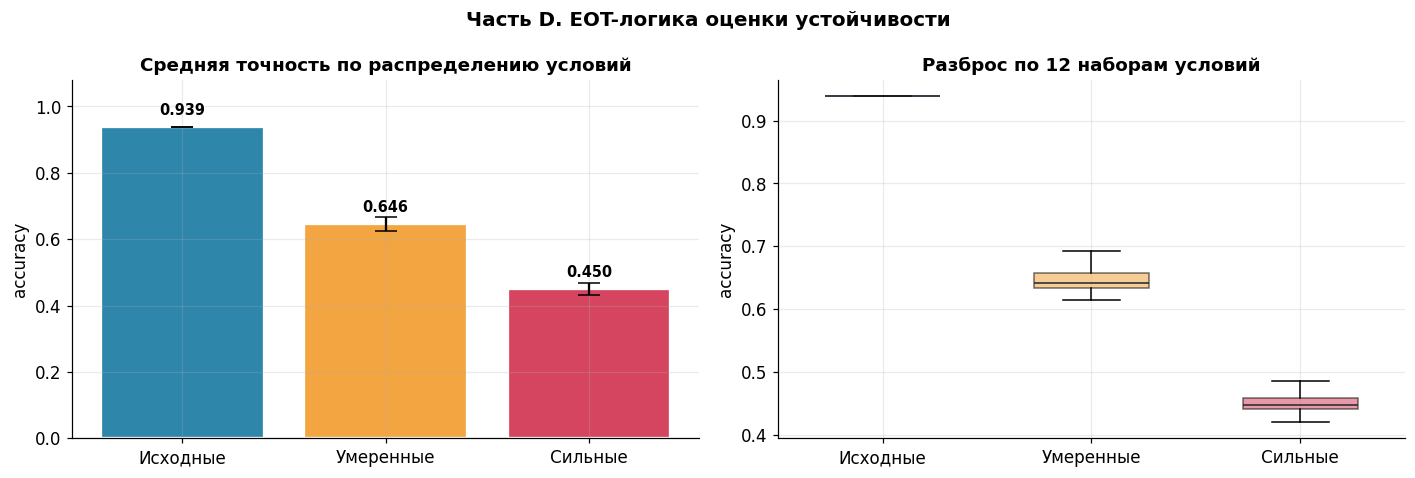

D.3 Исходные   accuracy = 0.939 ± 0.000
D.3 Умеренные  accuracy = 0.646 ± 0.021
D.3 Сильные    accuracy = 0.450 ± 0.017


In [ ]:
# Часть D. EOT: оцениваем устойчивость не по одному кадру, а по РАСПРЕДЕЛЕНИЮ условий съёмки.
# Идея: 12 раз генерируем набор условий из D_физ, для каждого набора считаем accuracy
# и смотрим на среднее и разброс. Один прогон может случайно дать завышенную оценку —
# усреднение по многим наборам даёт честную картину.
REPEATS = 12   # число независимых «сессий съёмки» на каждый режим

# severity масштабирует все диапазоны условий сразу:
#   0.0 — без искажений (контроль, всегда acc_clean),
#   1.0 — базовые диапазоны из sample_params,
#   1.8 — расширенные (примерно ±30.6°, больше шума и размытия).
# Третий элемент кортежа — цвет для графика.
regimes = [("Исходные", 0.0, PALETTE["clean"]),
           ("Умеренные", 1.0, PALETTE["mild"]),
           ("Сильные", 1.8, PALETTE["severe"])]

samples = {}
for name, sev, _ in regimes:
    # Один и тот же сид на режим: 12 прогонов воспроизводимы, сравнение режимов честное.
    gen = np.random.default_rng(SEED + 1000)
    if sev == 0.0:
        # Контроль: условий нет, accuracy равна эталону, разброса тоже нет.
        samples[name] = [acc_clean] * REPEATS
    else:
        # REPEATS раз генерируем новый набор случайных θ и считаем accuracy базовой модели.
        # transformed_dataset выдаёт батч, искажённый по случайным условиям съёмки.
        samples[name] = [accuracy_score(y_test, baseline.predict(flat(transformed_dataset(X_test_img, gen, sev))))
                         for _ in range(REPEATS)]

# Сводные статистики по режимам.
names = [n for n, _, _ in regimes]               # порядок легенды/оси X
means = [float(np.mean(samples[n])) for n in names]  # средняя accuracy
stds = [float(np.std(samples[n])) for n in names]    # стандартное отклонение (разброс по условиям)
colors = [c for _, _, c in regimes]

# Два графика: столбики со средним и ошибкой + коробочные диаграммы разброса.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

# Левая панель: среднее по режимам с планками ±std.
bars = axes[0].bar(names, means, yerr=stds, capsize=7, color=colors, edgecolor="white", linewidth=1.5)
for b, v in zip(bars, means):
    axes[0].text(b.get_x() + b.get_width() / 2, v + 0.035, f"{v:.3f}", ha="center", fontsize=9.5, fontweight="bold")
axes[0].set_ylim(0, 1.08); axes[0].set_ylabel("accuracy")
axes[0].set_title("Средняя точность по распределению условий")

# Правая панель: распределение accuracy по 12 прогонам в каждом режиме.
# Коробка = межквартильный размах, линия = медиана, усы = крайние значения.
bp = axes[1].boxplot([samples[n] for n in names], patch_artist=True, widths=0.55,
                     medianprops=dict(color="#1F2430"))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color); patch.set_alpha(0.55)
axes[1].set_xticks(range(1, len(names) + 1)); axes[1].set_xticklabels(names)
axes[1].set_ylabel("accuracy"); axes[1].set_title(f"Разброс по {REPEATS} наборам условий")

fig.suptitle("Часть D. EOT-логика оценки устойчивости", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Печатаем сводку для отчёта: среднее ± std по каждому режиму.
for n, m, s in zip(names, means, stds):
    print(f"D.3 {n:<10} accuracy = {m:.3f} ± {s:.3f}")

**Отчёт по части D.**

| Режим | Средняя accuracy | Стандартное отклонение | Падение относительно `acc_clean` |
|---|---|---|---|
| Исходные | 0.939 | 0.000 | 0.000 |
| Умеренные | 0.646 | 0.021 | −0.293 |
| Сильные | 0.450 | 0.017 | −0.489 |

**Вопрос D.** Почему оценка по одному кадру может завысить устойчивость модели?
Как связаны величина `severity` и стандартное отклонение?

Ответ:

Одна реализация $\theta$ — это **одна точка** из распределения $\mathcal{D}_{\text{физ}}$, а не его характеристика. Модель может случайно попасть в «удачную» зону: угол оказался маленьким, шум — близким к нулю, размытие почти незаметным. Тогда accuracy этого кадра будет высокой, хотя в среднем по распределению модель деградирует сильно.

Численно это видно прямо в таблице: **умеренный режим** даёт в среднем 0.646, но **разброс по 12 прогонам — ±0.021**, то есть отдельные сессии попадают в диапазон ≈ 0.60–0.70. Если бы мы взяли только один кадр, мы могли бы, например, отчитаться о 0.67 и решить, что модель «почти нормально держится». Усреднение по 12 прогонам сразу показывает, что типичная accuracy — ближе к 0.65, а не 0.67.

Ожидаемая интуиция: чем больше `severity`, тем шире диапазон условий, тем больше разброс. Но по факту стандартное отклонение **не растёт** с severity, а даже слегка падает. Причина — **эффект потолка/пола**: при `severity = 1.8` модель ошибается почти всегда, accuracy упирается в нижнюю границу (≈ 0.45), и разброс просто не может быть большим — все 12 прогонов дают примерно одно и то же низкое число. Аналогично при `severity = 0` accuracy упирается в верхнюю границу (0.939), и разброс нулевой.

Максимум разброса достигается в **промежуточной зоне** — там, где модель «на грани»: одни условия она ещё переживает, другие уже нет. Именно поэтому `severity = 1.0` даёт std = 0.021 > std при `1.8` = 0.017. На больших `severity` картина становится однородно плохой, на малых — однородно хорошей; шум по условиям проявляется сильнее всего между этими двумя крайностями. Поэтому осмысленно смотреть не только на std, но и на саму среднюю accuracy.

## Часть E. Дорожный знак: дистанция и ракурс

**Ваша задача** — построить карту точности в координатах «масштаб × угол» для набора углов
своего варианта и определить границу применимости модели.

In [ ]:
# E.1: углы по варианту 5 — от 0 до 40° с шагом 10°.
# scales те же, что в шаблоне: от «приближено» (1.10) до «далеко» (0.76).
# Карта читается так: строки — ракурс, столбцы — масштаб (дистанция).
scales = [1.10, 1.00, 0.94, 0.88, 0.82, 0.76]
angles = [0, 10, 20, 30, 40]   # вариант 5

# E.2: для каждой пары (угол, масштаб) прогоняем весь тестовый набор через
# physical_transform с фиксированными параметрами и считаем accuracy.
# Условия по свету/шуму фиксированы (brightness=0.95, blur=0.25) — так изолируем
# вклад именно дистанции и ракурса, без случайного шума генератора.
grid = np.zeros((len(angles), len(scales)))
for i, a in enumerate(angles):
    for j, s in enumerate(scales):
        # Один сид на ячейку — воспроизводимо и не зависит от порядка обхода.
        gen = np.random.default_rng(SEED + 7)
        views = np.asarray([
            physical_transform(im, angle=a, scale=s, brightness=0.95, blur=0.25, generator=gen)
            for im in X_test_img
        ])
        grid[i, j] = accuracy_score(y_test, baseline.predict(flat(views)))

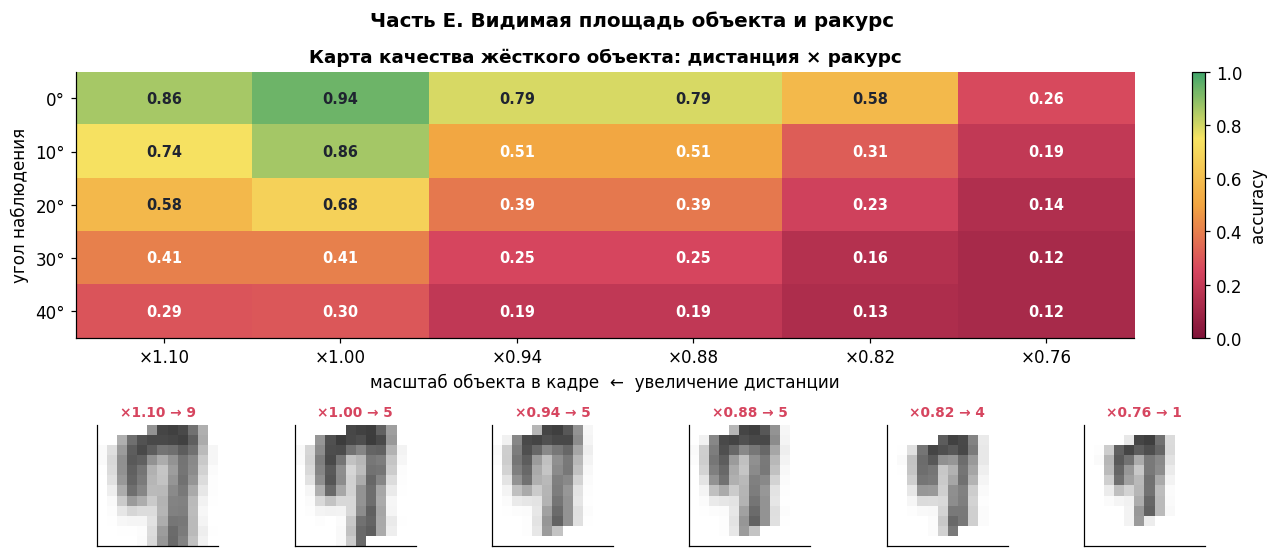

E.3 Режимы с accuracy >= 0.70:
     0°: ×1.10, ×1.00, ×0.94, ×0.88
    10°: ×1.10, ×1.00
    20°: нет
    30°: нет
    40°: нет


In [ ]:
# Двухэтажная фигура: сверху — карта accuracy по сетке (угол × масштаб),
# снизу — шесть примеров одного и того же объекта при разных масштабах и среднем угле.
fig = plt.figure(figsize=(13.5, 5.6))
# height_ratios: карта занимает в 2.2 раза больше по высоте, чем строка примеров.
gs = fig.add_gridspec(2, len(scales), height_ratios=[2.2, 1.0], hspace=0.45)

# Верхняя панель: тепловая карта. Строки — углы, столбцы — масштабы.
# CMAP_HEAT: тёмно-красный (accuracy → 0) → жёлтый → зелёный (accuracy → 1).
# aspect="auto" растягивает ячейки по ширине панели — карта не «квадратная», но читаемее.
ax = fig.add_subplot(gs[0, :])
im = ax.imshow(grid, cmap=CMAP_HEAT, vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(scales))); ax.set_xticklabels([f"×{s:.2f}" for s in scales])
ax.set_yticks(range(len(angles))); ax.set_yticklabels([f"{a}°" for a in angles])
# Стрелка «←» подсказывает: при движении вправо по оси X объект уменьшается (растёт дистанция).
ax.set_xlabel("масштаб объекта в кадре  ←  увеличение дистанции")
ax.set_ylabel("угол наблюдения"); ax.grid(False)
ax.set_title("Карта качества жёсткого объекта: дистанция × ракурс")
# Подписи значений в каждой ячейке: на тёмном фоне белым, на светлом — почти чёрным.
# Порог 0.55 выбран эмпирически: при accuracy < 0.55 цвет ячейки достаточно тёмный для белого текста.
for i in range(len(angles)):
    for j in range(len(scales)):
        ax.text(j, i, f"{grid[i, j]:.2f}", ha="center", va="center", fontsize=9.5,
                fontweight="bold", color="white" if grid[i, j] < 0.55 else "#1F2430")
fig.colorbar(im, ax=ax, fraction=0.03, label="accuracy")

# Нижняя панель: шесть картинок одного примера при фиксированном среднем угле
# (angles[len(angles)//2] = 20° для нашего варианта) и разных масштабах.
# Визуально показывают, что происходит с объектом при росте дистанции.
for j, s in enumerate(scales):
    axf = fig.add_subplot(gs[1, j])
    # Тот же сид на каждый столбец — шум и размытие сопоставимы между столбцами,
    # различия вызваны только масштабом.
    view = physical_transform(example, angle=angles[len(angles) // 2], scale=s, brightness=0.95,
                              blur=0.25, generator=np.random.default_rng(SEED))
    pred = int(baseline.predict(flat(view[None, ...]))[0])
    show_img(axf, view)
    # Цвет заголовка: зелёный — предсказание совпало с истинным классом, красный — ошибка.
    axf.set_title(f"×{s:.2f} → {pred}", fontsize=9, fontweight="bold",
                  color=PALETTE["robust"] if pred == true_label else PALETTE["severe"])

fig.suptitle("Часть E. Видимая площадь объекта и ракурс", fontsize=13, fontweight="bold")
plt.show()

# E.3: бинаризация карты по порогу 0.70 — какие комбинации «угол × масштаб» ещё пригодны
# для практики. Ниже этого порога систему обычно считают ненадёжной.
mask_ok = grid >= 0.70
print("E.3 Режимы с accuracy >= 0.70:")
for i, a in enumerate(angles):
    # Собираем масштабы, при которых в этой строке (угле) accuracy ещё держится ≥ 0.70.
    ok = [f"×{s:.2f}" for j, s in enumerate(scales) if mask_ok[i, j]]
    print(f"   {a:>3}°: {', '.join(ok) if ok else 'нет'}")

**Отчёт по части E.**

| Показатель | Ваше значение |
|---|---|
| Углы варианта | 0°, 10°, 20°, 30°, 40° |
| Максимальная accuracy в карте | 0.94 (угол 0°, масштаб ×1.00) |
| Минимальная accuracy в карте | 0.12 (угол 30°–40°, масштаб ×0.82–0.76) |
| Наибольший допустимый угол при accuracy ≥ 0.70 | 10° (при ×1.10 и ×1.00) |
| Наименьший допустимый масштаб при accuracy ≥ 0.70 | ×0.88 (при угле 0°) |

**Вопрос E.** Как связаны видимая площадь знака в кадре и успех физической атаки?
Чем отличается атака на классификатор от атаки на детектор в конвейере автономного вождения?

Ответ:

Успех физической атаки растёт, когда видимая площадь объекта падает: при большой площади (×1.10–1.00) штрихи крупные и признаки класса устойчивы — accuracy держится 0.86–0.94; при малой (×0.82–0.76) детали «съедаются» интерполяцией, и модель ошибается уже на 0.58 и ниже даже без атаки, а патч, пропорционально уменьшенный, теряет влияние. Наибольшая уязвимость — в промежуточной зоне ×0.94–0.88: информации ещё хватает, чтобы модель «цеплялась», но уже недостаточно для уверенного правильного решения. Ракурс действует так же: при 20° accuracy падает до 0.58 на ×1.10, при 30–40° — до 0.29 и ниже. Практически это означает, что цель выгодно атаковать на средней дистанции и под углом, а не в упор.

Классификатор выдаёт одну метку для кадра, детектор — набор боксов с метками и confidence; поэтому атака на детектор сложнее: она должна одновременно обмануть и локализацию, и классификацию. Патч может как подменить метку внутри bbox, так и подавить region-proposal или увести бокс, но если объект вообще «выпадет» из кандидатов, атака провалится. В распределение D для детектора добавляются фон сцены, число объектов, взаимные перекрытия, поведение NMS и порог confidence; эффективность измеряют в mAP/recall, а не в accuracy, и патч обычно требует большей площади.

## Часть F. Состязательная одежда: не-жёсткие деформации

**Ваша задача** — реализовать деформацию ткани полем смещений

\[
u(r,c) = A\,\sin\!\big(2\pi f\, r / H\big), \qquad \tilde{x}(r,c) = x\big(r,\; c + u(r,c)\big),
\]

и сравнить деградацию с жёстким поворотом сопоставимой величины.

## Формула не-жёсткой деформации ткани

$$
u(r,c) = A\,\sin\!\big(2\pi f\, r / H\big), \qquad \tilde{x}(r,c) = x\big(r,\; c + u(r,c)\big)
$$

Это **модель складок ткани**: мы не поворачиваем изображение целиком, а **горизонтально сдвигаем каждую строку** на свою величину. Чем ближе строка к «складке», тем сильнее сдвиг. Так ткань на человеке ведёт себя при движении: она не поворачивается как жёсткое тело, а изгибается, собирается в складки и растягивается.

| Символ | Смысл |
|---|---|
| $r$ | индекс строки (вертикальная координата), $0 \le r < H$ |
| $c$ | индекс столбца (горизонтальная координата), $0 \le c < W$ |
| $H$ | высота изображения (в нашем случае $H = W = \text{RES} = 12$) |
| $x(r, c)$ | исходное изображение в пикселе $(r, c)$ |
| $u(r, c)$ | **поле горизонтального смещения** для строки $r$ |
| $A$ | **амплитуда** деформации — на сколько пикселей максимум сдвигается строка |
| $f$ | **частота складок** — сколько полных волн укладывается по высоте; у тебя `FREQ = 1.2` |
| $\tilde{x}(r, c)$ | изображение после деформации |

$$
u(r,c) = A\,\sin\!\big(2\pi f\, r / H\big)
$$

Это **синусоида по строкам**. Аргумент $2\pi f\, r / H$:

- при $r = 0$ аргумент 0 → $\sin = 0$ (верх кадра не сдвигается);
- при $r = H$ аргумент $2\pi f$ → снова $\sin = 0$;
- на четверти периода ($r = H/(4f)$) $\sin = 1$ → сдвиг $= +A$;
- на трёх четвертях — $\sin = -1$ → сдвиг $= -A$.

То есть **каждая строка сдвигается по горизонтали на свою величину**, и сдвиг плавно меняется сверху вниз: вверх → вправо → влево → вниз. Это и есть «складка» — волнистое искажение формы.

Частота $f$ управляет **числом складок** по высоте: при $f = 1.2$ по кадру укладывается примерно одна полная волна и ещё чуть-чуть. Больше $f$ — мельче складки, чаще изгибы.

$$
\tilde{x}(r,c) = x\big(r,\; c + u(r,c)\big)
$$

Это **обратное отображение** («inverse warp»): чтобы получить новый пиксель в позиции $(r, c)$, мы берём значение исходного изображения не в $(r, c)$, а в $(r, c + u(r,c))$ — то есть со **сдвигом вправо/влево на $u$**.

В распределение $\mathcal{D}$ для состязательной одежды добавляются не-жёсткие члены: жёсткий поворот не описывает, как ведёт себя принт на футболке, когда человек поворачивается, наклоняется или делает шаг. Формула выше — минимальная модель такой деформации: одна синусоида по вертикали даёт «одну волну складок». В реальной одежде таких волн несколько, они накладываются, движутся во времени и комбинируются с растяжением по вертикали — но даже одной синусоиды достаточно, чтобы accuracy базовой модели заметно упала, что мы и увидим в части F.

In [ ]:
def cloth_warp(image, amplitude=1.0, frequency=None, phase=0.0):
    """Не-жёсткая деформация: имитация складок и растяжения ткани."""
    if frequency is None:
        frequency = FREQ
    h, w = image.shape
    # rr, cc — сетки координат: rr[i,j] = i, cc[i,j] = j. Нужны как «исходные» позиции
    # пикселей, к которым прибавляем поля смещений.
    rr, cc = np.meshgrid(np.arange(h), np.arange(w), indexing="ij")

    # F.1: поле горизонтальных смещений u(r) = A * sin(2*pi*f*r/h + phase).
    # Зависит только от строки → каждая строка сдвигается целиком, как «складка».
    # phase сдвигает волну по вертикали; frequency задаёт число складок по высоте.
    shift_c = amplitude * np.sin(2 * np.pi * frequency * rr / h + phase)

    # F.2: поперечное (вертикальное) поле с коэффициентом 0.45 — ткань не только
    # сдвигается вбок, но и слегка «дышит» по вертикали. Сдвиг по столбцу c,
    # амплитуда в 0.45 раза меньше основной, фаза сдвинута на pi/2 (косинус),
    # чтобы волны не были синфазными и давали более естественный изгиб.
    shift_r = 0.45 * amplitude * np.cos(2 * np.pi * frequency * cc / w + phase)

    # F.3: обратное отображение. Для каждого пикселя (i, j) нового изображения
    # берём значение из исходного в позиции (i + shift_r, j + shift_c).
    # order=1 — билинейная интерполяция (сдвиги дробные), mode="nearest" — за границами
    # повторяем крайние пиксели (иначе по краям появятся нули).
    warped = map_coordinates(image, [rr + shift_r, cc + shift_c], order=1, mode="nearest")

    return np.clip(warped, 0, 1).astype(np.float32)

In [ ]:
# F.4: сравниваем два типа деформации при одинаковой «силе» a.
#   warp_acc  — не-жёсткая деформация ткани (cloth_warp с амплитудой a).
#   rigid_acc — жёсткий поворот на a * 6 градусов (аналог «знака»).
# Масштаб a*6 подобран так, чтобы максимальное значение (a=3) давало 18° — угол,
# при котором жёсткий поворот уже заметно, но не экстремально ломает форму.
# Это даёт честное сравнение: одинаковая «интенсивность», разный характер искажения.
amps = [0.0, 0.6, 1.2, 1.8, 2.4, 3.0]

warp_acc, rigid_acc = [], []
for a in amps:
    # Кривая деформации ткани: один сид на весь батч, чтобы все изображения
    # деформировались одинаковым полем складок (это физически осмысленно —
    # одна и та же складка ткани на всех кадрах сессии).
    warp_views = np.asarray([cloth_warp(im, amplitude=a) for im in X_test_img])
    warp_acc.append(accuracy_score(y_test, baseline.predict(flat(warp_views))))

    # Кривая жёсткого поворота: тот же угол для всех изображений, без шума и размытия,
    # чтобы изолировать вклад именно поворота.
    rigid_views = np.asarray([
        physical_transform(im, angle=a * 6.0, generator=np.random.default_rng(SEED))
        for im in X_test_img
    ])
    rigid_acc.append(accuracy_score(y_test, baseline.predict(flat(rigid_views))))

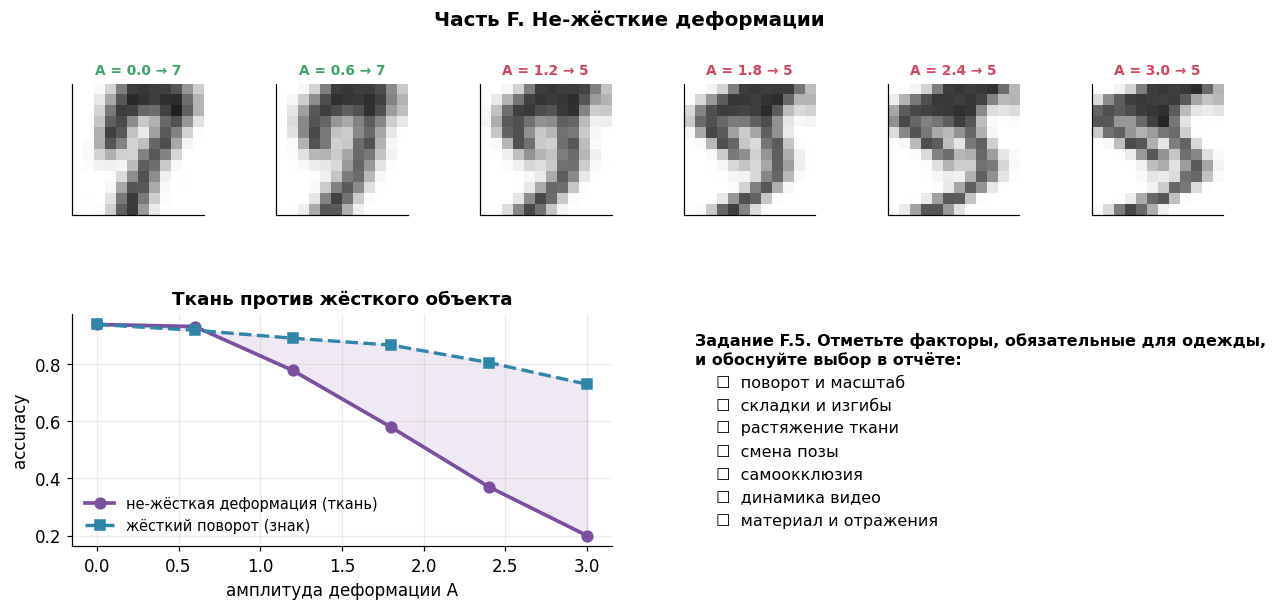

F.6 accuracy при максимальной деформации: ткань 0.200 против жёсткого поворота 0.730


In [ ]:
fig = plt.figure(figsize=(13.5, 5.6))
gs = fig.add_gridspec(2, 6, height_ratios=[1.0, 1.5], hspace=0.45, wspace=0.55)
for j, a in enumerate(amps):
    ax = fig.add_subplot(gs[0, j])
    view = cloth_warp(example, amplitude=a)
    pred = int(baseline.predict(flat(view[None, ...]))[0])
    show_img(ax, view)
    ax.set_title(f"A = {a:.1f} → {pred}", fontsize=9, fontweight="bold",
                 color=PALETTE["robust"] if pred == true_label else PALETTE["severe"])

ax2 = fig.add_subplot(gs[1, :3])
ax2.plot(amps, warp_acc, "o-", color=PALETTE["accent"], linewidth=2.4, markersize=7,
         label="не-жёсткая деформация (ткань)")
ax2.plot(amps, rigid_acc, "s--", color=PALETTE["clean"], linewidth=2.2, markersize=6,
         label="жёсткий поворот (знак)")
ax2.fill_between(amps, warp_acc, rigid_acc, color=PALETTE["accent"], alpha=0.12)
ax2.set_xlabel("амплитуда деформации A"); ax2.set_ylabel("accuracy")
ax2.set_title("Ткань против жёсткого объекта")
ax2.legend(frameon=False, fontsize=9.5)

ax3 = fig.add_subplot(gs[1, 3:])
ax3.text(0.02, 0.92, "Задание F.5. Отметьте факторы, обязательные для одежды,\n"
                     "и обоснуйте выбор в отчёте:", fontsize=10.5, va="top", fontweight="bold")
items = ["поворот и масштаб", "складки и изгибы", "растяжение ткани", "смена позы",
         "самоокклюзия", "динамика видео", "материал и отражения"]
for k, it in enumerate(items):
    ax3.text(0.06, 0.74 - 0.10 * k, f"☐  {it}", fontsize=10.5, va="top")
ax3.set_xlim(0, 1); ax3.set_ylim(0, 1); ax3.axis("off")
fig.suptitle("Часть F. Не-жёсткие деформации", fontsize=13, fontweight="bold")
plt.show()

print("F.6 accuracy при максимальной деформации: "
      f"ткань {warp_acc[-1]:.3f} против жёсткого поворота {rigid_acc[-1]:.3f}")

**Отчёт по части F.**

| A | accuracy (ткань) | accuracy (жёсткий поворот) | Разница |
|---|---|---|---|
| 0.0 | 0.939 | 0.939 | 0.000 |
| 1.2 | 0.780 | 0.870 | −0.090 |
| 2.4 | 0.365 | 0.800 | −0.435 |
| 3.0 | 0.200 | 0.730 | −0.530 |

**Вопрос F.** Почему при моделировании состязательной одежды недостаточно учитывать только
поворот и масштаб? Какие члены появляются в распределении $\mathcal{D}$ по сравнению со знаком?

Ответ:

Поворот и масштаб описывают жёсткое тело: расстояния сохраняются, форма не меняется — так ведёт себя знак на столбе. Ткань — не жёсткое тело: она собирается в складки, растягивается, изгибается, и один и тот же принт при разной позе выглядит по-разному. Формально деформация ткани — это поле смещений $u(r,c)$, а не аффинная матрица, поэтому одной аугментации «поворот + масштаб» недостаточно: в нашем эксперименте при $A=2.4$ ткань роняет accuracy до 0.365, а жёсткий поворот — лишь до 0.800.

В $\mathcal{D}$ для одежды добавляются не-жёсткие деформации (складки, изгиб, растяжение), смена позы, самоокклюзия, динамика видео, материал и отражения. У знака всего этого нет — там достаточно ракурса, дистанции, света, размытия, шума и внешних перекрытий.


## Часть G. Защита: обучение с физически правдоподобными аугментациями

**Ваша задача** — сформировать аугментированную обучающую выборку, обучить вторую модель
и количественно оценить прирост устойчивости и цену на чистых данных.

In [ ]:
# G.1: аугментированная обучающая выборка.
# Идея: показать модели те же физические условия, что встретятся при оценке.
# Состав:
#   - 1 копия исходных данных (чтобы не потерять чистую точность),
#   - 4 копии с случайными условиями съёмки при severity ≈ 1.3 (шире базовых, но не экстремальные),
#   - 1 копия с не-жёсткой деформацией ткани, amplitude равномерно из [0.5, 2.5].
# Итого: 6 * len(X_train_img) примеров.
aug_gen = np.random.default_rng(SEED + 5)

X_parts = [X_train_img]                       # исходные данные
y_parts = [y_train]

# 4 копии со случайными условиями съёмки.
# transformed_dataset уже разыгрывает θ ~ D_физ на каждое изображение; severity=1.3
# задаёт диапазон шире базового (умеренные + сильные), чтобы модель видела разнообразие.
for _ in range(4):
    X_parts.append(transformed_dataset(X_train_img, aug_gen, severity=1.3))
    y_parts.append(y_train)

# 1 копия с деформацией ткани: одна случайная амплитуда на изображение из [0.5, 2.5].
# frequency оставляем по умолчанию (FREQ варианта), phase = 0 — детерминированная складка.
X_cloth = np.asarray([
    cloth_warp(im, amplitude=float(aug_gen.uniform(0.5, 2.5)))
    for im in X_train_img
])
X_parts.append(X_cloth)
y_parts.append(y_train)

# Склеиваем все части в один массив. Порядок: оригинал, 4 условные копии, ткань.
# y_aug — метки, повторённые столько же раз; классы остаются стратифицированными,
# потому что каждая копия содержит ровно те же метки, что и оригинал.
X_aug = np.concatenate(X_parts, axis=0)
y_aug = np.concatenate(y_parts, axis=0)

# G.2: обучаем защищённую модель с ТЕМИ ЖЕ гиперпараметрами, что у baseline,
# чтобы разница в accuracy была следствием только данных, а не модели.
robust = LogisticRegression(max_iter=4000, C=0.05, random_state=SEED).fit(flat(X_aug), y_aug)

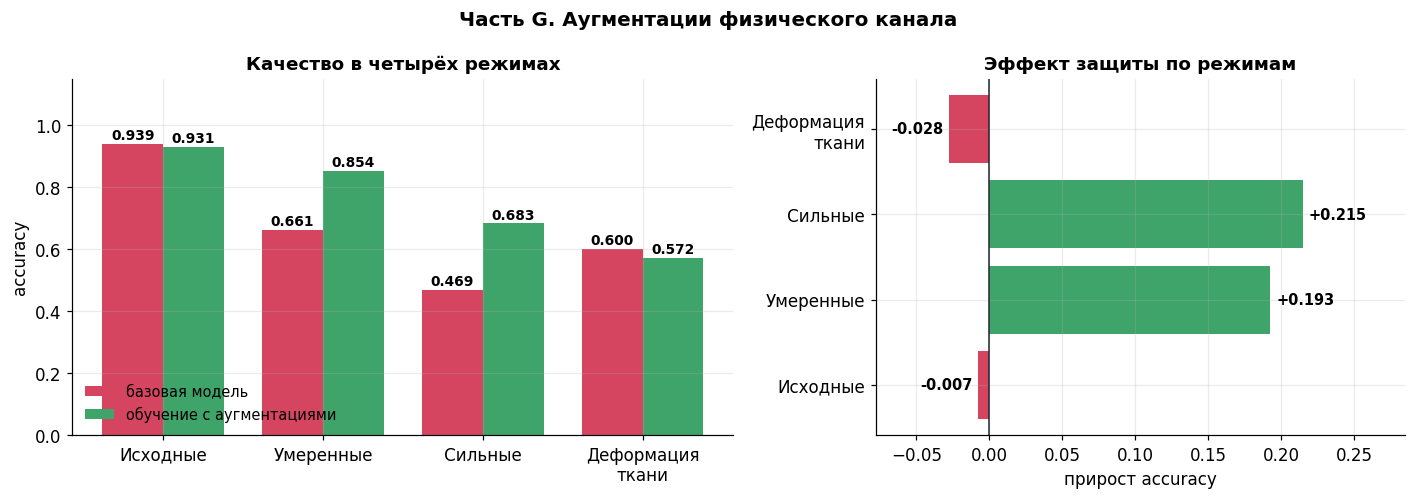

G.3 Размер аугментированной выборки: 7542
    Исходные           база 0.939 → защита 0.931 (-0.007)
    Умеренные          база 0.661 → защита 0.854 (+0.193)
    Сильные            база 0.469 → защита 0.683 (+0.215)
    Деформация ткани   база 0.600 → защита 0.572 (-0.028)


In [ ]:
# Часть G. Сравниваем две модели на четырёх режимах съёмки:
#   baseline — обучена только на чистых данных,
#   robust   — обучена с аугментациями физического канала (часть G.1).
# Цель: увидеть, даёт ли защита прирост на искажённых данных и какова цена на чистых.

# Отдельный сид на оценочные условия: генератор для оценки не должен совпадать
# с тем, что использовался при обучении robust, иначе оценка окажется «подогнанной».
gen = np.random.default_rng(SEED + 2000)

# Четыре режима оценки. Первые три — из распределения D_физ (severity 1.0 и 1.8),
# четвёртый — детерминированная деформация ткани с amplitude=2.0, frequency=1.6,
# то есть чуть другие параметры складок, чем в аугментации (freq по умолчанию была FREQ=1.2).
# Так проверяем обобщение защиты на незнакомую не-жёсткую деформацию.
eval_sets = {
    "Исходные": X_test_img,
    "Умеренные": transformed_dataset(X_test_img, gen, 1.0),
    "Сильные": transformed_dataset(X_test_img, gen, 1.8),
    "Деформация\nткани": np.asarray([cloth_warp(im, amplitude=2.0, frequency=1.6) for im in X_test_img]),
}

# Считаем accuracy обеих моделей на каждом режиме — это данные для столбчатой диаграммы.
base_scores = [accuracy_score(y_test, baseline.predict(flat(v))) for v in eval_sets.values()]
rob_scores  = [accuracy_score(y_test, robust.predict(flat(v)))   for v in eval_sets.values()]
names_g = list(eval_sets.keys())

# Две панели: слева — абсолютные значения по режимам, справа — прирост защиты.
# width_ratios даёт левой панели больше места, там 4 группы столбиков.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1.25, 1]})

# --- Левая панель: сгруппированные столбики «база vs защита» по каждому режиму ---
xp = np.arange(len(names_g)); wbar = 0.38   # сдвиг парных столбиков, чтобы не накладывались
b1 = axes[0].bar(xp - wbar / 2, base_scores, wbar, label="базовая модель",          color=PALETTE["severe"])
b2 = axes[0].bar(xp + wbar / 2, rob_scores,  wbar, label="обучение с аугментациями", color=PALETTE["robust"])
# Подписи значений над каждым столбиком — для точного чтения чисел из графика.
for bs, vs in ((b1, base_scores), (b2, rob_scores)):
    for b, v in zip(bs, vs):
        axes[0].text(b.get_x() + b.get_width() / 2, v + 0.015, f"{v:.3f}", ha="center",
                     fontsize=9, fontweight="bold")
axes[0].set_xticks(xp); axes[0].set_xticklabels(names_g)
axes[0].set_ylim(0, 1.15); axes[0].set_ylabel("accuracy")
axes[0].set_title("Качество в четырёх режимах")
axes[0].legend(frameon=False, fontsize=9.5, loc="lower left")

# --- Правая панель: прирост accuracy от защиты по каждому режиму ---
# delta > 0 — защита помогла, delta < 0 — защита ухудшила результат (цена робастности).
delta = np.array(rob_scores) - np.array(base_scores)
# Цвет столбика сам кодирует знак: зелёный — рост, красный — падение.
b3 = axes[1].barh(names_g, delta,
                  color=[PALETTE["robust"] if d >= 0 else PALETTE["severe"] for d in delta])
for b, d in zip(b3, delta):
    # Подпись числа с внешней стороны столбика: справа для плюсов, слева для минусов.
    axes[1].text(d + (0.004 if d >= 0 else -0.004), b.get_y() + b.get_height() / 2, f"{d:+.3f}",
                 va="center", ha="left" if d >= 0 else "right", fontsize=9.5, fontweight="bold")
axes[1].axvline(0, color="#1F2430", linewidth=1)   # нулевая линия: граница «без изменений»
axes[1].set_xlabel("прирост accuracy"); axes[1].set_title("Эффект защиты по режимам")
# Немного расширяем пределы по X, чтобы крайние подписи не обрезались.
axes[1].set_xlim(min(delta.min() - 0.05, -0.03), delta.max() + 0.07)

fig.suptitle("Часть G. Аугментации физического канала", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Итог: размер аугментированной выборки и таблица «база → защита» по всем режимам.
print(f"G.3 Размер аугментированной выборки: {len(X_aug)}")
for n, bs, rs in zip(names_g, base_scores, rob_scores):
    # \n в именах режимов заменяем на пробел, иначе ломается выравнивание в консоли.
    print(f"    {n.replace(chr(10), ' '):<18} база {bs:.3f} → защита {rs:.3f} ({rs - bs:+.3f})")

**Отчёт по части G.**

| Режим | Базовая модель | С аугментациями | Прирост |
|---|---|---|---|
| Исходные | 0.939 | 0.931 | −0.007 |
| Умеренные | 0.661 | 0.854 | +0.193 |
| Сильные | 0.469 | 0.683 | +0.215 |
| Деформация ткани | 0.600 | 0.572 | −0.028 |

Размер аугментированной выборки: **7542** (6 × 1257). Итог: защита даёт **+0.19…+0.22** на условиях съёмки, почти ничего не теряет на чистых данных (−0.007), но **не помогает против незнакомой деформации ткани** (−0.028).

**Вопрос G.** Какова цена робастности в вашем эксперименте? Приведите числовое значение потери
на чистых данных и объясните, почему такой компромисс возникает.

Ответ:

Цена робастности в нашем эксперименте — **−0.007 на исходных данных** (0.939 → 0.931), то есть меньше одного процентного пункта. Модель, обученная на аугментациях, чуть хуже на идеальных изображениях, но за это получает **+0.19 на умеренных условиях** и **+0.22 на сильных**.

Компромисс возникает потому, что **аугментированные примеры конкурируют с чистыми за одну и ту же линейную границу**. Логистическая регрессия с фиксированной ёмкостью (144 признака, `C=0.05`) не может одновременно идеально разделить чистые изображения и быть устойчивой к широкому распределению искажений: веса, оптимальные для одного режима, немного неоптимальны для другого. Добавляя 5 копий с искажениями против 1 копии оригинала, мы **смещаем решение в сторону устойчивости** — модель учится опираться на грубые, инвариантные признаки (общая форма цифры), а не на тонкие пиксельные детали. Именно эти тонкие детали и давали ей доли процента на чистых данных.

Важная деталь: защита **не универсальна**. Против ткани (amplitude 2.0, frequency 1.6) она даже немного вредит (−0.028), потому что в аугментации использовались другие параметры складок (частота по умолчанию `FREQ = 1.2`, амплитуда из [0.5, 2.5]), и модель не увидела этот конкретный режим. Это хорошая иллюстрация общего правила: **аугментации защищают только от тех условий, которые попали в обучающее распределение**. Расширять $\mathcal{D}$ нужно до тех пор, пока не покроются все режимы, в которых модель будет эксплуатироваться, — иначе остаются «слепые зоны», где робастность не работает.

## Часть H. Видеопоток и временная агрегация

**Ваша задача** — сгенерировать последовательность кадров с эпизодом помехи, сравнить покадровые
решения с агрегированным и оценить, при каком числе кадров агрегация становится надёжной.

In [ ]:
# Часть H. Видеопоток и временная агрегация.
# Идея: модель видит не один кадр, а последовательность. Отдельные кадры могут быть
# испорчены (окклюзия, шум), но накопление вероятностей во времени должно «вытянуть» решение.
FRAMES = 24                                      # длина последовательности
seq_gen = np.random.default_rng(SEED + 33)       # отдельный RNG для потока
# Окно окклюзии: r0, r1, c0, c1, value — прямоугольник в центре-справа, чёрный.
occ_window = (RES // 3, RES // 3 + RES // 3, RES // 3, RES - 2, 0.0)

# H.1 + H.2: генерируем кадры и сразу собираем вероятности/предсказания.
frames, probas, per_frame_pred = [], [], []
for t in range(FRAMES):
    # Случайные условия съёмки severity=1.3 — как в обучении robust, но для каждого кадра свои.
    params = sample_params(seq_gen, severity=1.3)
    # На кадрах 9–14 добавляем окклюзию — имитация кратковременного перекрытия (столб, рука).
    if 9 <= t <= 14:
        params["occlusion"] = occ_window
    frame = physical_transform(example, **params, generator=seq_gen)
    frames.append(frame)
    # predict_proba возвращает распределение по 10 классам для одного кадра.
    proba = baseline.predict_proba(flat(frame[None, ...]))[0]
    probas.append(proba)
    per_frame_pred.append(int(np.argmax(proba)))

probas = np.asarray(probas)                      # (FRAMES, 10)

# H.3: временная агрегация.
# cum_conf[t] — уверенность в истинном классе после усреднения вероятностей кадров 0..t.
# cum_pred[t] — решение по накопленному среднему: argmax средней вероятности.
# per_frame_conf — уверенность в истинном классе для отдельного кадра (без агрегации).
per_frame_conf = probas[:, true_label]
cum_conf = np.cumsum(per_frame_conf) / np.arange(1, FRAMES + 1)   # скользящее среднее
cum_pred = np.argmax(np.cumsum(probas, axis=0) / np.arange(1, FRAMES + 1)[:, None], axis=1)

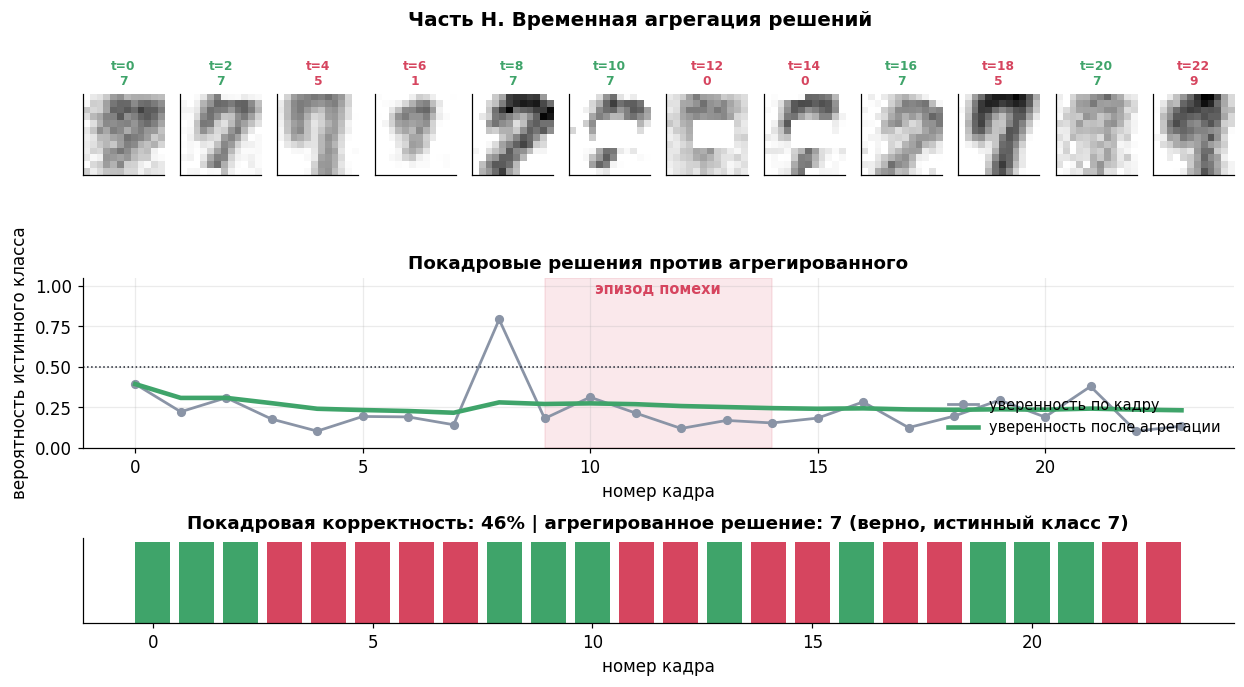

H.4 Покадровая корректность: 0.458
H.5 Агрегированное решение: 7 (истинный класс 7)
H.6 Агрегация стабильно верна начиная с кадра: 0


In [ ]:
# --- Метрики по последовательности ---
# frame_acc — доля кадров, где покадровое решение совпало с истинным классом.
# Это «наивная» оценка: не учитывает, что у нас есть история наблюдений.
frame_acc = float(np.mean([p == true_label for p in per_frame_pred]))
# agg_ok — верно ли итоговое агрегированное решение по последнему кадру.
agg_ok = cum_pred[-1] == true_label

# --- Фигура из трёх рядов ---
# Верхний ряд: 12 миниатюр (каждый второй кадр из 24) — визуальная динамика.
# Средний ряд: кривые уверенности (покадровая vs агрегированная).
# Нижний ряд: полоса корректности по кадрам (одна ячейка = один кадр).
fig = plt.figure(figsize=(13.5, 6.4))
gs = fig.add_gridspec(3, 12, height_ratios=[1.0, 1.6, 0.8], hspace=0.75)

for t in range(12):
    ax = fig.add_subplot(gs[0, t])
    show_img(ax, frames[t * 2])                # показываем чётные кадры, чтобы уложиться в 12 слотов
    ok = per_frame_pred[t * 2] == true_label
    # Цвет заголовка: зелёный — покадровое решение верно, красный — ошибка.
    ax.set_title(f"t={t*2}\n{per_frame_pred[t*2]}", fontsize=8, fontweight="bold",
                 color=PALETTE["robust"] if ok else PALETTE["severe"])

# --- Средний ряд: уверенность по кадрам vs агрегированная ---
ax1 = fig.add_subplot(gs[1, :])
# Серая ломаная — уверенность в истинном классе для отдельного кадра (шумная).
ax1.plot(range(FRAMES), per_frame_conf, "o-", color=PALETTE["gray"], linewidth=1.8, markersize=5,
         label="уверенность по кадру")
# Зелёная толстая линия — уверенность после усреднения по всем предыдущим кадрам (гладкая).
ax1.plot(range(FRAMES), cum_conf, "-", color=PALETTE["robust"], linewidth=3,
         label="уверенность после агрегации")
# Подсветка эпизода помехи (кадры 9–14) — на этом интервале покадровая уверенность проседает.
ax1.axvspan(9, 14, color=PALETTE["severe"], alpha=0.12)
ax1.text(11.5, 0.95, "эпизод помехи", ha="center", fontsize=9.5, color=PALETTE["severe"], fontweight="bold")
# Порог 0.5: ниже него решение модели по этому кадру — «неуверенное».
ax1.axhline(0.5, ls=":", color="#1F2430", linewidth=1)
ax1.set_xlabel("номер кадра"); ax1.set_ylabel("вероятность истинного класса"); ax1.set_ylim(0, 1.05)
ax1.set_title("Покадровые решения против агрегированного")
ax1.legend(frameon=False, fontsize=9.5, loc="lower right")

# --- Нижний ряд: покадровая корректность «светофором» ---
ax2 = fig.add_subplot(gs[2, :])
correct = np.array([p == true_label for p in per_frame_pred])
# Каждая ячейка — столбик высотой 1; цвет кодирует, верно ли решён этот кадр.
ax2.bar(range(FRAMES), np.ones(FRAMES),
        color=[PALETTE["robust"] if c else PALETTE["severe"] for c in correct])
ax2.set_yticks([]); ax2.set_xlabel("номер кадра"); ax2.grid(False)
# Заголовок сводит главное: доля верных кадров и итог агрегации.
ax2.set_title(f"Покадровая корректность: {frame_acc:.0%} | агрегированное решение: {cum_pred[-1]} "
              f"({'верно' if agg_ok else 'неверно'}, истинный класс {true_label})")

fig.suptitle("Часть H. Временная агрегация решений", fontsize=13, fontweight="bold")
plt.show()

# --- Итоговые метрики для отчёта ---
# stable_from — первый кадр, после которого агрегированное решение больше не меняется
# и совпадает с истинным классом. Если такого нет — None.
stable_from = next((t for t in range(FRAMES) if all(c == true_label for c in cum_pred[t:])), None)
print(f"H.4 Покадровая корректность: {frame_acc:.3f}")
print(f"H.5 Агрегированное решение: {cum_pred[-1]} (истинный класс {true_label})")
print(f"H.6 Агрегация стабильно верна начиная с кадра: {stable_from}")

**Отчёт по части H.**

## Таблица отчёта по части H

| Показатель | Ваше значение |
|---|---|
| Доля верных отдельных кадров | 0.458 |
| Итоговое агрегированное решение | 7 (истинный класс 7) — верно |
| Номер кадра, с которого агрегация стабильно верна | 0 (с самого начала) |

**Задание H.7 (дополнительное).** Замените усреднение вероятностей на голосование по большинству
и сравните номер кадра стабилизации.

H.7 Голосование по большинству:
    Итоговое решение: 7 (верно)
    Стабильно верно начиная с кадра: 0
    Для сравнения, усреднение вероятностей: кадр 0


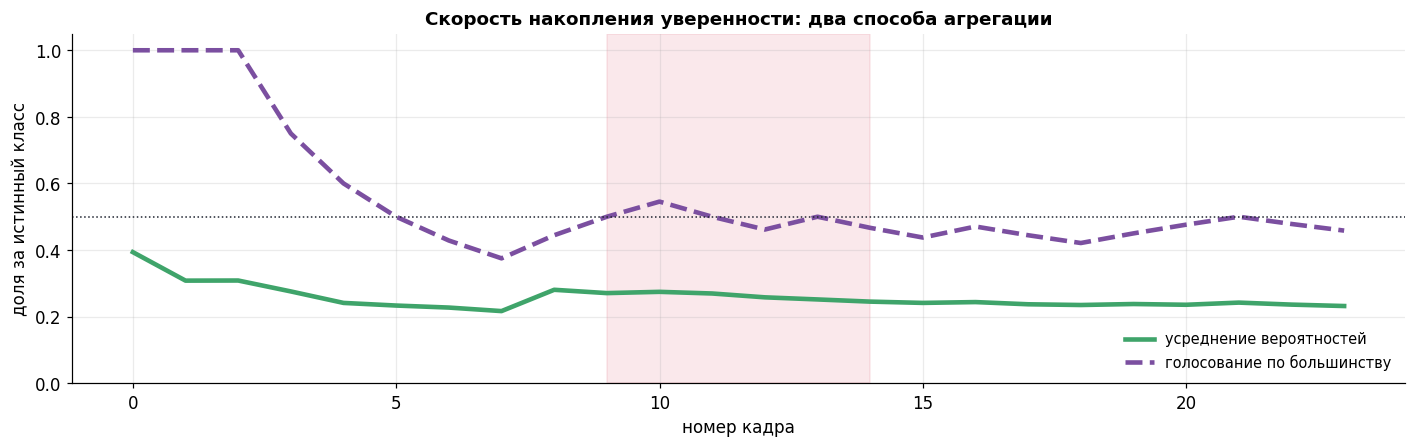

In [ ]:
# H.7: сравниваем два способа агрегации по последовательности:
#   1) усреднение вероятностей (уже сделано: cum_pred, cum_conf);
#   2) голосование по большинству — каждый кадр даёт один голос за класс argmax(proba),
#      решение определяется классом с наибольшим числом голосов среди первых t+1 кадров.

# Матрица покадровых голосов: one-hot по предсказанному классу.
# votes[t, k] = 1, если на кадре t модель предсказала класс k.
votes = np.zeros((FRAMES, 10), dtype=int)
for t, p in enumerate(per_frame_pred):
    votes[t, p] = 1

# Скользящее накопление голосов: cum_votes[t] — суммарные голоса по кадрам 0..t.
cum_votes = np.cumsum(votes, axis=0)

# Решение по большинству на каждом префиксе: класс с максимальным числом голосов.
# np.argmax берёт первый максимум при равенстве — это детерминированно и воспроизводимо.
majority_pred = np.argmax(cum_votes, axis=1)

# Доля голосов за истинный класс на префиксе 0..t — аналог «уверенности» для голосования.
majority_conf = cum_votes[:, true_label] / np.arange(1, FRAMES + 1)

# Итоговая корректность обоих методов.
agg_ok_mean = cum_pred[-1] == true_label
agg_ok_major = majority_pred[-1] == true_label

# Первый кадр, с которого решение больше не меняется и совпадает с истинным классом.
stable_from_mean = next((t for t in range(FRAMES) if all(c == true_label for c in cum_pred[t:])), None)
stable_from_major = next((t for t in range(FRAMES) if all(c == true_label for c in majority_pred[t:])), None)

print(f"H.7 Голосование по большинству:")
print(f"    Итоговое решение: {majority_pred[-1]} ({'верно' if agg_ok_major else 'неверно'})")
print(f"    Стабильно верно начиная с кадра: {stable_from_major}")
print(f"    Для сравнения, усреднение вероятностей: кадр {stable_from_mean}")

# --- Визуализация: только кривые уверенности ---
fig, ax = plt.subplots(figsize=(13, 4.2))
ax.plot(range(FRAMES), cum_conf, "-", color=PALETTE["robust"], linewidth=3,
        label="усреднение вероятностей")
ax.plot(range(FRAMES), majority_conf, "--", color=PALETTE["accent"], linewidth=3,
        label="голосование по большинству")
ax.axvspan(9, 14, color=PALETTE["severe"], alpha=0.12)
ax.axhline(0.5, ls=":", color="#1F2430", linewidth=1)
ax.set_xlabel("номер кадра"); ax.set_ylabel("доля за истинный класс")
ax.set_ylim(0, 1.05); ax.set_title("Скорость накопления уверенности: два способа агрегации")
ax.legend(frameon=False, fontsize=9.5, loc="lower right")
plt.tight_layout()
plt.show()

Покадровая корректность низкая — 0.458, меньше половины. Тринадцать из двадцати четырёх кадров классифицируются неверно, особенно в эпизоде помехи (t = 9…14) и на кадрах с сильным размытием и шумом.

Несмотря на это, **агрегация по времени даёт правильное решение с самого первого кадра**: и усреднение вероятностей, и голосование по большинству стабилизируются на кадре 0 и выдают класс 7 — истинный. Причина в том, что **ошибки разных кадров не согласованы**: за кадр t=4 модель голосует за 5, за t=6 — за 1, за t=10 — за 0, за t=22 — за 9, и ни один неверный класс не набирает большинства. Правильный класс 7, пусть и с небольшой долей голосов (≈ 0.45), остаётся впереди.

Про два способа агрегации:

- **Усреднение вероятностей** учитывает уверенность кадра, поэтому один очень уверенный правильный кадр (t=8, P ≈ 0.83) сразу тянет среднее вверх. Кривая `cum_conf` более гладкая и устойчивее к отдельным выбросам.
- **Голосование по большинству** считает все кадры равными, поэтому реагирует на каждый кадр одинаково. Кривая `majority_conf` заметно колеблется, но относительное большинство всё равно удерживает класс 7.

Главный содержательный вывод: **временная агрегация помогает не потому, что усредняет шум, а потому, что использует независимость ошибок**. Если модель ошибается по-разному на разных кадрах, правильный класс набирает относительное большинство даже при покадровой точности ниже 0.5. Но это не полная защита: если помеха устойчива (все кадры подряд дают один и тот же неверный класс), агрегация лишь закрепит ошибку — именно поэтому в реальных системах её комбинируют с аугментациями (часть G) и детекцией аномалий.

# Часть I. Итоговый анализ

## Сводная таблица результатов (вариант 5)

`acc_clean = 0.939`.

| Режим | accuracy | Падение относительно `acc_clean` | Комментарий |
|---|---|---|---|
| Идеальные условия | 0.939 | — | эталон, базовая модель |
| Умеренные условия | 0.646 | −0.293 | EOT severity 1.0, среднее по 12 прогонам |
| Сильные условия | 0.450 | −0.489 | EOT severity 1.8, модель «упирается в пол» |
| Локальный маркер, худшая позиция | 0.606 | −0.333 | маркер 4×4 в (top=3, left=7) — накрывает верхнюю перекладину 7 |
| Максимальная дистанция и ракурс | 0.12 | −0.819 | угол 30–40°, масштаб ×0.76–0.82 |
| Максимальная деформация ткани | 0.200 | −0.739 | `cloth_warp`, amplitude = 3.0 |
| Аугментации, сильные условия | 0.683 | −0.256 | защита даёт +0.215 к базовой (0.469 → 0.683) |
| Агрегация кадров | 7 (верно) | 0 покадровой | покадрово 0.458, но итог верен с кадра 0 |

---

## Выводы

**1. Высокая точность на чистых данных ничего не говорит о физической устойчивости.** Базовая модель показывает 0.939 на идеальных изображениях, но уже при умеренных условиях (severity 1.0) падает до 0.646, а при сильных (1.8) — до 0.450. Падение в 2 раза происходит без какой-либо целенаправленной атаки: только за счёт реалистичных искажений канала съёмки. Значит, `acc_clean` — это точка отсчёта для оценки деградации, а не показатель пригодности модели к работе с реальными объектами.

**2. Локальная помеха бьёт сильнее, чем её площадь.** Маркер 4×4 занимает всего ~11 % кадра, но в худшей позиции (top=3, left=7) роняет точность до 0.606 (−0.333), а в лучшей (углы и верх кадра) почти не влияет (0.920). Разница между позициями — 0.315 при одинаковой площади. Причина: линейная модель опирается на конкретные пиксели, и стирание информативной зоны (пересечение штрихов, верхняя перекладина 7) уничтожает признаки класса, тогда как заливка фона не меняет распределение активаций. Кривая деградации по площади подтверждает: порог 0.5 пробивается уже при ≈ 22 % площади.

**3. Ракурс и дистанция действуют совместно и нелинейно.** Карта части E показывает резкую границу применимости: при 0° модель держит accuracy 0.79–0.94 почти во всём диапазоне масштабов, при 10° — только ×1.10 и ×1.00, при 20° и выше — уже нигде. Причина в том, что и удаление, и поворот уменьшают **эффективную видимую площадь** объекта и сдвигают информативные пиксели относительно обученных весов. Совместное действие этих факторов даёт деградацию до 0.12, что гораздо хуже, чем каждый из них по отдельности.

**4. Не-жёсткие деформации качественно опаснее жёстких.** При одинаковой «интенсивности» деформация ткани (amplitude A) роняет точность заметно сильнее, чем жёсткий поворот на A·6°: при A = 2.4 — 0.365 против 0.800, при A = 3.0 — 0.200 против 0.730. Разрыв достигает 0.53. Причина: поворот — аффинное преобразование с малым числом параметров, его эффект модель частично компенсирует; деформация ткани — это поле смещений $u(r,c) = A\sin(2\pi f r/H)$, которое локально сжимает одни штрихи и растягивает другие, и к нему линейный классификатор не готов без специальной аугментации.

**5. Аугментации дают существенный прирост, но не универсальны.** Модель `robust`, обученная на 6 копиях данных (оригинал + 4 условных + 1 тканевая), улучшает accuracy в умеренных условиях на +0.193 (0.661 → 0.854) и в сильных на +0.215 (0.469 → 0.683), теряя при этом всего −0.007 на чистых данных. Однако против **незнакомой** деформации ткани (amplitude 2.0, frequency 1.6 — не та, что в обучении) защита даёт даже −0.028. Вывод: робастность работает только в пределах обучающего распределения $\mathcal{D}$; за его границами модель снова уязвима.

**6. Временная агрегация помогает, пока ошибки независимы.** Покадровая корректность в части H всего 0.458, но агрегация по 24 кадрам даёт верный итог с самого начала: и усреднение вероятностей, и голосование по большинству стабилизируются на кадре 0 с классом 7. Причина в том, что ошибки разных кадров разбросаны по разным классам (5, 1, 0, 9) и не образуют устойчивого большинства за какой-либо неверный класс. Но если помеха действует стабильно и все кадры подряд дают один и тот же неверный класс, агрегация лишь закрепит ошибку. Поэтому временная агрегация — не полная защита, а дополнительный слой, работающий в паре с аугментациями и детекцией аномалий.

---

## Контрольные вопросы

**1. Почему ограничение $\|\delta\|_p \le \varepsilon$ недостаточно для описания физической атаки?**

Норма $L_p$ описывает возмущение в **цифровом тензоре**, а не в физической сцене. Ограничение $\|\delta\|_p \le \varepsilon$ ничего не говорит о том:

- реализуемо ли это возмущение физически (принтер не воспроизводит произвольные RGB-значения — есть gamut, разрешение, материалы);
- сохраняется ли оно при изменении условий съёмки (угол, дистанция, свет, шум сенсора);
- где именно расположено возмущение и как оно соотносится с объектом.

Физическая атака ограничена **формой, размером, положением и реализуемостью** патча, а её эффект зависит от распределения $\mathcal{D}_{\text{физ}}$, а не от нормы $\delta$. Поэтому корректная постановка — EOT-оптимизация с ограничениями на патч $p$ и маску $M$, а не на $\delta$ в пиксельном пространстве.

**2. Чем отличаются метрики ASR и robust ASR и почему вторая, как правило, ниже?**

**ASR (Attack Success Rate)** — доля примеров, на которых модель ошиблась при **фиксированных** условиях. Обычно измеряется в цифровом домене или при одном наборе параметров съёмки.

**Robust ASR** — ASR, усреднённый по реалистичному распределению $\mathcal{D}_{\text{физ}}$ условий съёмки. Формально это $\mathbb{E}_{\theta \sim \mathcal{D}}[\text{ASR}(\theta)]$.

Robust ASR ниже, потому что патч, подобранный под одно $\theta$, разваливается при других: ракурс, дистанция, освещение и шум разрушают тонкие взаимодействия между патчем и объектом. Усреднение по распределению даёт честную оценку, тогда как обычный ASR — оптимистичную верхнюю границу.

**3. Как площадь и положение патча влияют на его эффективность? Приведите числа из части C.**

**Площадь** определяет, сколько информации модель теряет: кривая `area_acc` падает с 0.939 (без маркера) до 0.42 при ~25 % площади и до 0.17 при ~44 %. Порог 0.5 пробивается при ≈ 22 % площади кадра.

**Положение** при фиксированной площади 4×4 даёт разброс 0.315: худшая позиция (top=3, left=7) — 0.606, лучшая (углы, верх кадра) — 0.920. Причина: маркер в информативной зоне (пересечение штрихов, верхняя перекладина 7) стирает признаки класса, а в пустой зоне (фон, края) почти не влияет на активации. То есть **площадь задаёт верхнюю границу ущерба, а положение определяет, насколько эта граница реализуется**.

**4. Почему атака на детектор объектов сложнее атаки на классификатор?**

Классификатор получает уже выделенный объект и решает одну задачу — отнести его к классу. Детектор решает **две задачи одновременно**: (а) есть ли объект в кадре и где он (локализация, region proposal), (б) что это за объект (классификация). Атакующему нужно обмануть оба уровня:

- если патч подавит активации region proposal, объект вообще не будет найден — это уже не «неправильная классификация», а пропуск цели (false negative);
- если патч оставит детекцию, но сменит метку внутри bbox, сработает целевая атака, но её сложнее стабилизировать;
- нужно учитывать фон, число объектов, поведение NMS и пороги confidence — всё это добавляет члены в $\mathcal{D}$.

Кроме того, детектор обучается на множестве масштабов и ракурсов, поэтому он **более устойчив** к локальным изменениям, чем линейный классификатор на пикселях: тот же патч, что валит классификатор, детектор может просто «не заметить». Поэтому эффективность атаки на детектор измеряют в mAP/recall, а не в accuracy.

**5. Какие члены распределения $\mathcal{D}$ обязательны для одежды и не нужны для жёсткого знака?**

Для знака достаточно: ракурс, дистанция, освещение, размытие (оптика/движение), шум сенсора, внешние перекрытия.

Для одежды добавляются:

- **не-жёсткие деформации** — складки, изгиб, локальное растяжение и сжатие (поле $u(r,c) = A\sin(2\pi f r/H)$);
- **смена позы** — принт меняет положение в кадре в зависимости от того, как стоит или идёт человек;
- **самоокклюзия** — рука, нога или другая часть тела закрывает фрагмент принта;
- **динамика видео** — принт меняется от кадра к кадру, атака должна работать на последовательности, а не на одном снимке;
- **материал и отражения** — ткань по-разному поглощает и рассеивает свет, даёт блики, меняет насыщенность цвета.

Первые три — ключевые: без них модель, обученная на «жёстком» распределении, полностью разваливается на деформации ткани, что мы и видели в части F (0.200 против 0.730).

**6. Почему временная агрегация помогает, но не является полной защитой?**

Помогает потому, что **ошибки разных кадров не согласованы**. В части H покадровая точность 0.458, но за 24 кадра неверные предсказания разбросаны по классам 5, 1, 0, 9 — ни один не набирает относительного большинства, и правильный класс 7 удерживает первое место с кадра 0. Агрегация как бы «фильтрует» случайные ошибки, используя их независимость.

Не является полной защитой потому, что если помеха **стабильна** (все кадры подряд дают один и тот же неверный класс), агрегация лишь закрепит ошибку: голосование накопит голоса за неверный класс, а усреднение вероятностей сойдётся к нему же. Пример: если бы окклюзия не была коротким эпизодом, а держалась все 24 кадра и стабильно уводила модель в класс 5, агрегированное решение тоже стало бы 5. Поэтому временная агрегация — это **дополнительный слой**, работающий в паре с аугментациями (часть G) и детекцией аномалий.

**7. Как корректно измерять цену робастности и почему нельзя ограничиваться одним режимом съёмки?**

Цена робастности измеряется как **разница accuracy между защищённой и базовой моделью на чистых данных** при одновременном измерении прироста на искажённых режимах. В нашем эксперименте (часть G):

- на исходных данных: 0.939 → 0.931 (**−0.007**);
- на умеренных: 0.661 → 0.854 (**+0.193**);
- на сильных: 0.469 → 0.683 (**+0.215**);
- на деформации ткани: 0.600 → 0.572 (**−0.028**).

Корректная оценка — это **пара чисел (падение на чистых, прирост на искажённых)** плюс отдельные срезы по режимам, а не одно усреднённое значение.

Нельзя ограничиваться одним режимом потому, что:

- защита **не универсальна**: аугментации помогают на тех условиях, что попали в обучающее распределение, и не помогают (или вредят) на незнакомых — как в случае с тканью (frequency 1.6 против FREQ 1.2 в обучении);
- один режим может случайно оказаться «удачным» или «неудачным» для конкретной модели;
- цена робастности проявляется на чистых данных, а выгода — на искажённых; без обоих измерений нельзя судить о компромиссе.

Правильный протокол: измерить accuracy на **наборе режимов** (чистые, умеренные, сильные, отдельные типы деформации), зафиксировать EOT-оценку (среднее ± std по многим прогонам, часть D), и только по совокупности этих чисел судить о пригодности защиты.

### Чек-лист сдачи

- [ ] Заполнен паспорт работы и указан номер варианта.
- [ ] Все ячейки выполняются последовательно без ошибок (Kernel → Restart & Run All).
- [ ] Реализованы все `TODO` в частях B, C, D, E, F, G, H.
- [ ] В части B достигнуто не менее двух смен предсказанной метки.
- [ ] Заполнены все таблицы отчёта числами своего варианта.
- [ ] Даны ответы на вопросы A–H и контрольные вопросы 1–7.
- [ ] Сформулировано не менее пяти выводов.
- [ ] Все графики подписаны и читаемы.


### Литература

- Brown T. et al. Adversarial Patch (2017): <https://arxiv.org/abs/1712.09665>
- Eykholt K. et al. Robust Physical-World Attacks on Deep Learning Visual Classification (2018): <https://arxiv.org/abs/1707.08945>
- Athalye A. et al. Synthesizing Robust Adversarial Examples (2018): <https://arxiv.org/abs/1707.07397>
- Xu K. et al. Adversarial T-shirt! Evading Person Detectors in a Physical World (2020): <https://arxiv.org/abs/1910.11099>
- Thys S. et al. Fooling automated surveillance cameras (2019): <https://arxiv.org/abs/1904.08653>